In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train = pd.read_csv("data/train.csv")
val = pd.read_csv("data/val.csv")
test = pd.read_csv("data/holdout.csv")


print("TRAIN SHAPE:", train.shape)
print("TEST SHAPE :", val.shape)

print("\nTRAIN COLUMNS:")
print(train.columns.tolist())

t1 = "target_1"
t2 = "target_2"

# небольшое удаление двух выбросов 
train = train[~train[t1].isin([
    " 1 000 000 ",
    " 100 000 "
])].copy()

train[t1] = pd.to_numeric(
    train[t1].astype(str).str.replace(" ", "", regex=False)
)

train[t2] = pd.to_numeric(
    train[t2].astype(str).str.replace(" ", "", regex=False)
)



print("\nTARGET_1 describe")
print(train[t1].describe())

print("\nTARGET_2 describe")
print(train[t2].describe())

TRAIN SHAPE: (15109, 56)
TEST SHAPE : (2068, 56)

TRAIN COLUMNS:
['ID', 'REGION', 'BRANCH', 'CITY', 'subject', 'SUBFRMT', 'TRADE_SQUARE', 'HuffFamilies', 'HuffRelativeFamilies', 'HOSPITAL', 'KINDERGARTENS', 'BANKS', 'MK_ON_MM', 'ROUTES_CNT', 'CROSSWALK', 'CROSSROAD', 'DENSITY_FAMILY_TYPE', 'COLLEGES', 'huff_hotel', 'TRADING_PATCH_SCORE', 'RENT_HEX', 'IN_COAL_CITY', 'IN_OIL_CITY', 'CITY_TYPE', 'ON_DUPLICATE_ROAD', 'HUFF_RANK_COMPS_CANNIBALS', 'TOTAL_RANK_COMPS_CANNIBALS', 'INSIDE_YARD', 'ON_INSIDE_DISTRICT_ROAD', 'ON_MAIN_CITY_ROAD', 'ON_INTERCITY_HIGHWAY', 'ENTRANCE_TO_DISTRICT', 'ON_DISTRICT_BOTTOM', 'HUB', 'ALCOHOL', 'TOBACCO', 'LOCATION_MARKET', 'STATIONS', 'TRC', 'METRO', 'LOCATION_PARK', 'MINI_TRC', 'TRADING_PATCH', 'ENTIRE_DAY', 'MORNING_ROADSIDE', 'SEA', 'FLOORS_TZ', 'SNT', 'LOCATION_TYPE', 'DIST_TO_ADM_CENTER', 'PARKING', 'month_count', 'new_buildings', 'change_CA', 'target_1', 'target_2']

TARGET_1 describe
count     15107.000000
mean     266904.323259
std       83858.550714
m


Correlation TARGET_1 vs TARGET_2 = 0.977739

RATIO describe
count    15107.000000
mean         1.014698
std          0.063879
min          0.615641
25%          0.986791
50%          1.009012
75%          1.030905
max          2.437334
Name: target_ratio, dtype: float64

DIFF describe
count     15107.000000
mean       3147.905688
std       17695.715505
min     -208679.454559
25%       -3335.629872
50%        2147.357525
75%        7481.161423
max      353437.726052
Name: target_diff, dtype: float64


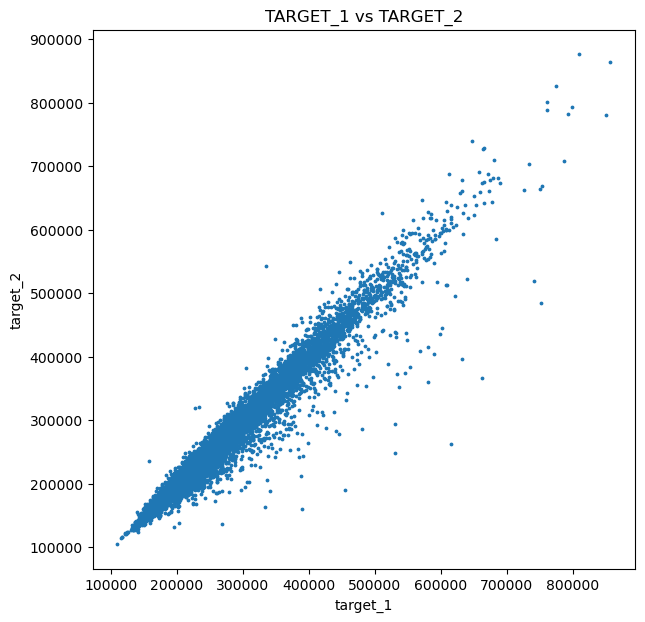

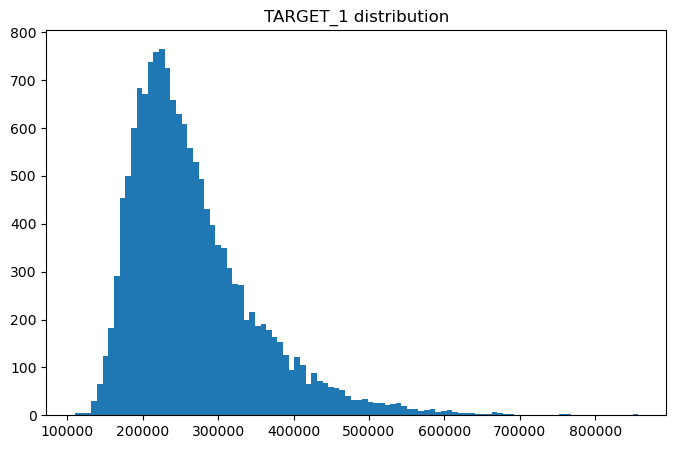

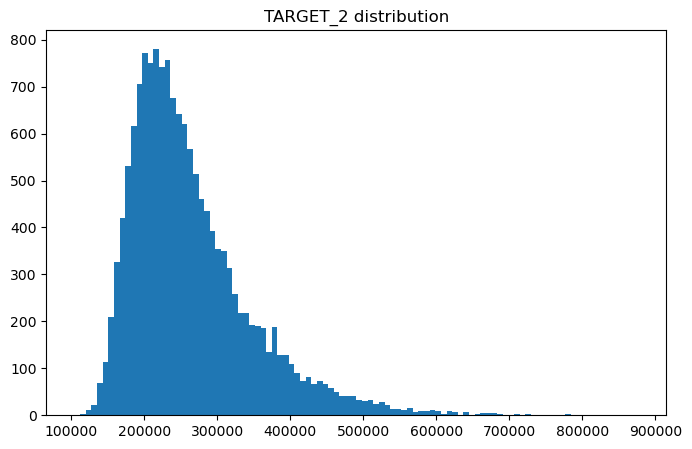

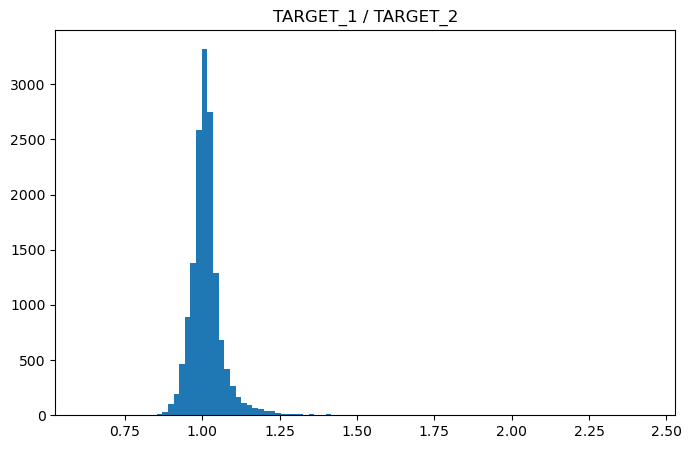

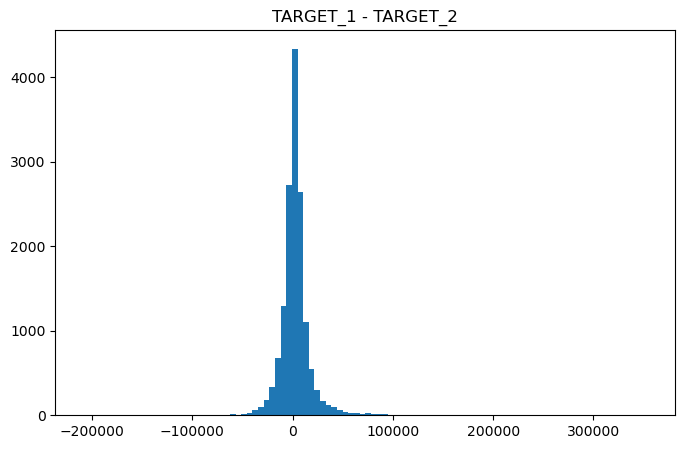


POSSIBLE DATETIME COLS: []

NO DATETIME COLUMN FOUND

TOP DRIFTED FEATURES:
('ID', np.float64(1.9690114922673534))
('month_count', np.float64(1.728164664859506))
('SUBFRMT', np.float64(1.193224239872473))
('new_buildings', np.float64(0.7919143601434566))
('HuffRelativeFamilies', np.float64(0.4534165484802438))
('target_1', np.float64(0.38843696670286715))
('ON_INTERCITY_HIGHWAY', np.float64(0.3660839340517315))
('target_2', np.float64(0.34223961195001934))
('MK_ON_MM', np.float64(0.33845743082654006))
('TRADING_PATCH_SCORE', np.float64(0.3237215036789454))
('HUFF_RANK_COMPS_CANNIBALS', np.float64(0.2653431099731976))
('TOTAL_RANK_COMPS_CANNIBALS', np.float64(0.26229709952038444))
('SNT', np.float64(0.2180754601827525))
('PARKING', np.float64(0.21506368839035805))
('DIST_TO_ADM_CENTER', np.float64(0.2055527318152877))
('DENSITY_FAMILY_TYPE', np.float64(0.19088519272258644))
('RENT_HEX', np.float64(0.18712137400328885))
('KINDERGARTENS', np.float64(0.18062820255687323))
('TRADE_SQUARE',

In [ ]:
# ========= CORRELATION =========
corr = train[[t1, t2]].corr().iloc[0,1]
print(f"\nCorrelation TARGET_1 vs TARGET_2 = {corr:.6f}")

# ========= RATIO / DIFFERENCE =========
eps = 1e-9

train["target_ratio"] = train[t1] / (train[t2] + eps)
train["target_diff"] = train[t1] - train[t2]

print("\nRATIO describe")
print(train["target_ratio"].describe())

print("\nDIFF describe")
print(train["target_diff"].describe())

# ========= SCATTER =========
sample_size = min(20000, len(train))

sample_df = train.sample(sample_size, random_state=42)

plt.figure(figsize=(7,7))
plt.scatter(
    sample_df[t1],
    sample_df[t2],
    s=3
)
plt.xlabel(t1)
plt.ylabel(t2)
plt.title("TARGET_1 vs TARGET_2")
plt.show()

# ========= HIST TARGETS =========
plt.figure(figsize=(8,5))
plt.hist(train[t1], bins=100)
plt.title("TARGET_1 distribution")
plt.show()

plt.figure(figsize=(8,5))
plt.hist(train[t2], bins=100)
plt.title("TARGET_2 distribution")
plt.show()

# ========= HIST RATIO =========
plt.figure(figsize=(8,5))
plt.hist(
    train["target_ratio"].replace([np.inf, -np.inf], np.nan).dropna(),
    bins=100
)
plt.title("TARGET_1 / TARGET_2")
plt.show()

# ========= HIST DIFF =========
plt.figure(figsize=(8,5))
plt.hist(train["target_diff"], bins=100)
plt.title("TARGET_1 - TARGET_2")
plt.show()


# ========= QUICK DRIFT CHECK =========
common_cols = [c for c in train.columns if c in val.columns]

numeric_cols = []

for c in common_cols:
    if pd.api.types.is_numeric_dtype(train[c]):
        numeric_cols.append(c)

drift_scores = []

for col in numeric_cols:

    tr = train[col].dropna()
    te = val[col].dropna()

    if len(tr) == 0 or len(te) == 0:
        continue

    mean_diff = abs(tr.mean() - te.mean())

    std = tr.std() + 1e-9

    drift = mean_diff / std

    drift_scores.append((col, drift))

drift_scores = sorted(
    drift_scores,
    key=lambda x: x[1],
    reverse=True
)

print("\nTOP DRIFTED FEATURES:")
for x in drift_scores[:30]:
    print(x)

In [ ]:
train[t1]

0         175198.181280689 
1         360629.424460479 
2         252109.534031112 
3         362653.018943467 
4         295733.315192993 
                ...        
15104      335833.03570864 
15105     239449.710720112 
15106     229265.834248059 
15107     279075.187488385 
15108     284443.300715194 
Name: target_1, Length: 15109, dtype: object

In [ ]:
# посмотреть какие значения не парсятся в float, и удалить их. Скорее всего это что-то испорченное 

bad_values = []

for v in train[t1].unique():
    try:
        float(v)
    except:
        bad_values.append(v)

print("BAD VALUES COUNT:", len(bad_values))

for x in bad_values[:50]:
    print(repr(x))

BAD VALUES COUNT: 2
' 1 000 000 '
' 100 000 '


In [10]:
special_mask = train[t1].isin([
    " 1 000 000 ",
    " 100 000 "
])

special_rows = train[special_mask]

print(special_rows.shape)

special_rows.head()

(2, 56)


,ID,REGION,BRANCH,CITY,subject,SUBFRMT,TRADE_SQUARE,HuffFamilies,HuffRelativeFamilies,HOSPITAL,...,FLOORS_TZ,SNT,LOCATION_TYPE,DIST_TO_ADM_CENTER,PARKING,month_count,new_buildings,change_CA,target_1,target_2
5817,5818,Московский округ,Москва 4,Москва,Москва город,2,0.825861,0.100464,0.88,0,...,1,0,3,17.990481,0,136,0,0,1 000 000,987449.405050
11249,11250,Московский округ,Москва 5,Одинцово,Московская область,1,0.576918,0.079154,0.64,0,...,1,0,1,1.246564,0,81,0,0,100 000,100057.205742


In [30]:
train[t1].describe()

count     15107.000000
mean     266904.323259
std       83858.550714
min      109333.196540
25%      208195.716667
50%      247124.692844
75%      305117.007299
max      857059.780902
Name: target_1, dtype: float64

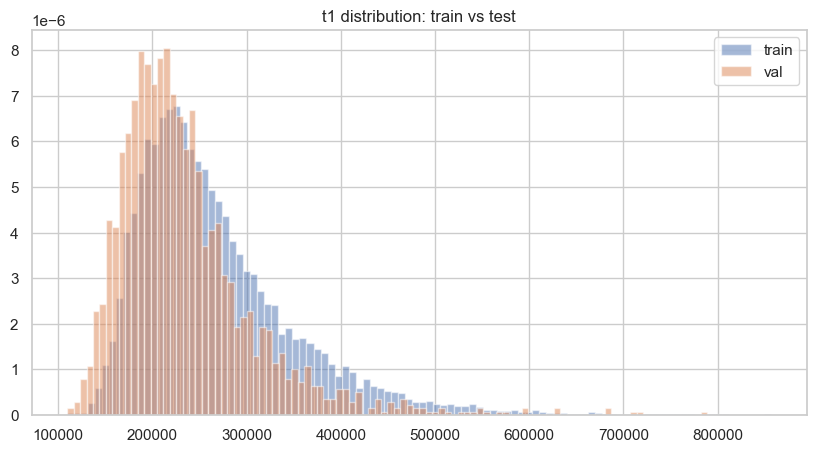

In [84]:
# в общем предполагаем что TARGET1 и TARGET2 это примерно ондо и то же и фиг с ними

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ========= CLEAN =========
train[t1] = pd.to_numeric(train[t1], errors="coerce")
val[t1]  = pd.to_numeric(val[t1], errors="coerce")


train_t1 = train[t1].dropna()
val_t1  = val[t1].dropna()



# ========= PLOTS =========
plt.figure(figsize=(10,5))
plt.hist(train_t1, bins=100, alpha=0.5, label="train", density=True)  # добавлено density=True
plt.hist(val_t1, bins=100, alpha=0.5, label="val", density=True)      # добавлено density=True


plt.legend()
plt.title("t1 distribution: train vs test")
plt.show()

train SUBFRMT == 1 count: 6114
val SUBFRMT == 1 count: 2048


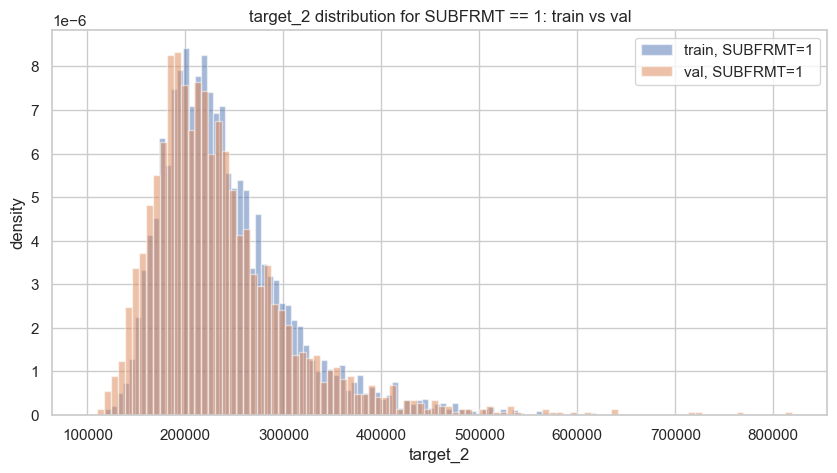

In [83]:
# target_2 distribution for SUBFRMT == 1

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ========= CLEAN =========
train['target_2'] = pd.to_numeric(train['target_2'], errors='coerce')
val['target_2'] = pd.to_numeric(val['target_2'], errors='coerce')

train_t2_subfrmt1 = train.loc[train['SUBFRMT'].eq(1), 'target_2'].dropna()
val_t2_subfrmt1 = val.loc[val['SUBFRMT'].eq(1), 'target_2'].dropna()

print(f'train SUBFRMT == 1 count: {len(train_t2_subfrmt1)}')
print(f'val SUBFRMT == 1 count: {len(val_t2_subfrmt1)}')

# ========= PLOTS =========
plt.figure(figsize=(10, 5))
plt.hist(train_t2_subfrmt1, bins=100, alpha=0.5, label='train, SUBFRMT=1', density=True)
plt.hist(val_t2_subfrmt1, bins=100, alpha=0.5, label='val, SUBFRMT=1', density=True)

plt.legend()
plt.title('target_2 distribution for SUBFRMT == 1: train vs val')
plt.xlabel('target_2')
plt.ylabel('density')
plt.show()


In [87]:
val['ENTIRE_DAY'].value_counts()

ENTIRE_DAY
0    1989
1      79
Name: count, dtype: int64

train SUBFRMT == 2 count: 8995
val all count: 2068


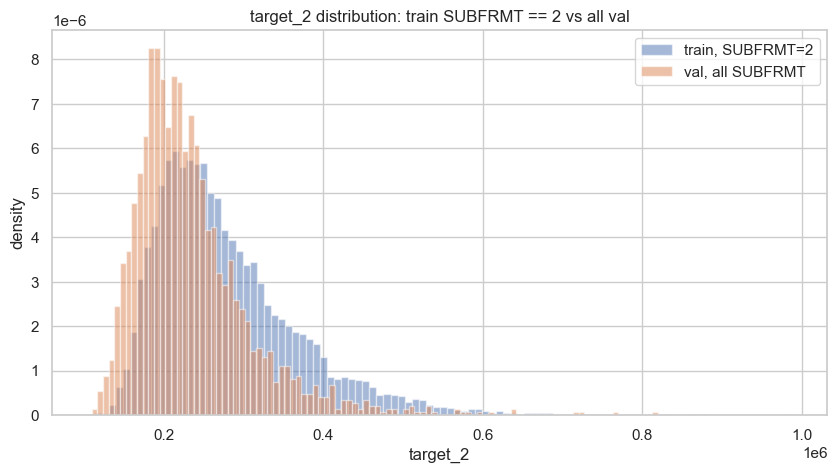

In [85]:
# target_2 distribution: all val vs train SUBFRMT == 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ========= CLEAN =========
train['target_2'] = pd.to_numeric(train['target_2'], errors='coerce')
val['target_2'] = pd.to_numeric(val['target_2'], errors='coerce')

train_t2_subfrmt2 = train.loc[train['SUBFRMT'].eq(2), 'target_2'].dropna()
val_t2_all = val['target_2'].dropna()

print(f'train SUBFRMT == 2 count: {len(train_t2_subfrmt2)}')
print(f'val all count: {len(val_t2_all)}')

# ========= PLOTS =========
plt.figure(figsize=(10, 5))
plt.hist(train_t2_subfrmt2, bins=100, alpha=0.5, label='train, SUBFRMT=2', density=True)
plt.hist(val_t2_all, bins=100, alpha=0.5, label='val, all SUBFRMT', density=True)

plt.legend()
plt.title('target_2 distribution: train SUBFRMT == 2 vs all val')
plt.xlabel('target_2')
plt.ylabel('density')
plt.show()


In [27]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15107 entries, 0 to 15108
Data columns (total 56 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          15107 non-null  int64  
 1   REGION                      15107 non-null  object 
 2   BRANCH                      15107 non-null  object 
 3   CITY                        15107 non-null  object 
 4   subject                     15107 non-null  object 
 5   SUBFRMT                     15107 non-null  int64  
 6   TRADE_SQUARE                15107 non-null  float64
 7   HuffFamilies                15107 non-null  float64
 8   HuffRelativeFamilies        15107 non-null  float64
 9   HOSPITAL                    15107 non-null  int64  
 10  KINDERGARTENS               15107 non-null  int64  
 11  BANKS                       15107 non-null  int64  
 12  MK_ON_MM                    15107 non-null  int64  
 13  ROUTES_CNT                  15107 no

## Анализ фичи `month_count`

Графики ниже сравнивают распределение `month_count` в train, val и holdout, а также показывают связь с таргетами там, где они доступны.


In [ ]:
print(train[feature].min()) # 37
print(train[feature].max()) # 318
print(val[feature].min()) # 13
print(val[feature].max()) # 36
print(test[feature].min()) # 1 
print(test[feature].max()) #12


37
318
13
36
1
12


## `month_count` и `target_1` в train

Один график для проверки, меняется ли `target_1` с возрастом магазина.


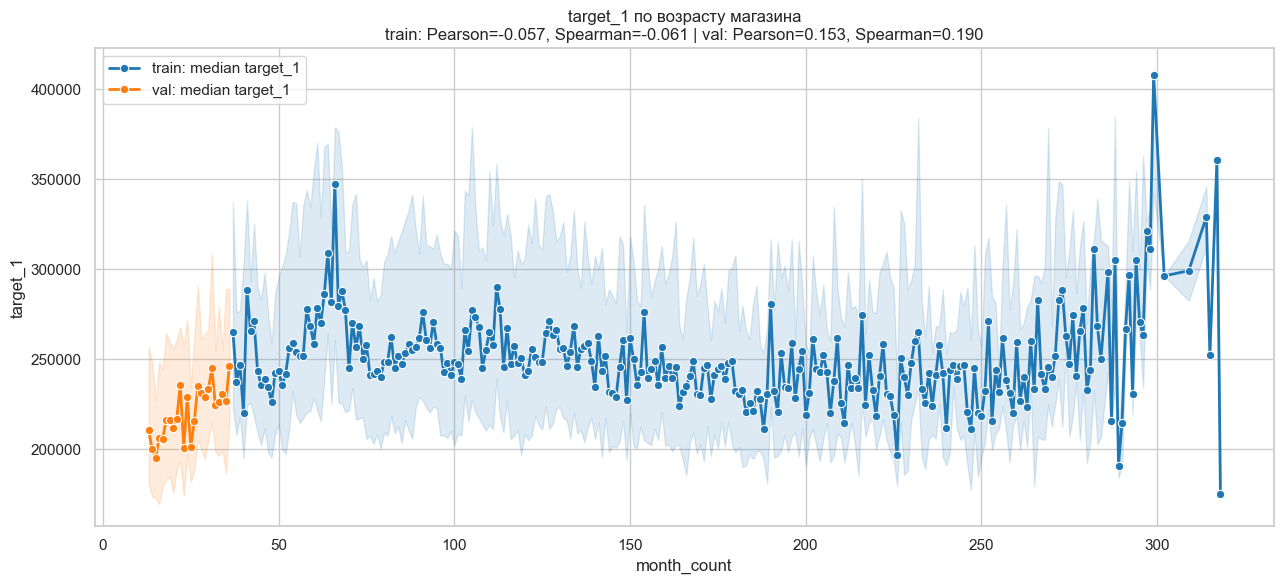

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', context='notebook')

DATA_DIR = Path('data')
train = pd.read_csv(DATA_DIR / 'train.csv')
val = pd.read_csv(DATA_DIR / 'val.csv')

feature = 'month_count'
target = 'target_1'

def prepare_part(df, dataset_name):
    part = df[[feature, target]].copy()
    part[target] = pd.to_numeric(part[target], errors='coerce')
    part = part.dropna(subset=[feature, target])
    part['dataset'] = dataset_name
    return part

plot_df = pd.concat(
    [
        prepare_part(train, 'train'),
        prepare_part(val, 'val'),
    ],
    ignore_index=True,
)

corr_text = []
for dataset_name, part in plot_df.groupby('dataset'):
    pearson = part[feature].corr(part[target], method='pearson')
    spearman = part[feature].corr(part[target], method='spearman')
    corr_text.append(f'{dataset_name}: Pearson={pearson:.3f}, Spearman={spearman:.3f}')

trend = (
    plot_df
    .groupby(['dataset', feature])[target]
    .agg(
        median='median',
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        count='size',
    )
    .reset_index()
)

palette = {'train': '#1f77b4', 'val': '#ff7f0e'}
plt.figure(figsize=(13, 6))

for dataset_name, part in trend.groupby('dataset'):
    color = palette[dataset_name]
    plt.fill_between(
        part[feature],
        part['q25'],
        part['q75'],
        color=color,
        alpha=0.15,
    )
    sns.lineplot(
        data=part,
        x=feature,
        y='median',
        marker='o',
        linewidth=2,
        color=color,
        label=f'{dataset_name}: median target_1',
    )

plt.title('target_1 по возрасту магазина\n' + ' | '.join(corr_text))
plt.xlabel('month_count')
plt.ylabel('target_1')
plt.legend()
plt.tight_layout()
plt.show()


видно, что нвоые магазины имеют меньше продаж, и постепенно набирают аудиторию. Проблема в том, что для совсем новых магазинов мы вообще не знаем что происходит, поэтому надо при моделировании решения учитывать 2 варианта (и выбрать лучший по качеству, то есть подстроиться под тест)) 
1) Тренд снизу вверх продолжится, и у новых магазинов будет прибыль еще меньше
2) Новые магазины будут приносить примерно столько же, сколько и открытые в 13-14 месяц, то есть тренд как бы не падал дальше 

Есть еще 1 гипотеза - selctive bias. Новые точки открывались в менее прибыльных локациях, потому что самые прибыльные уже заняты. 

Такжепо таким данным невозможно учитывать эффект новизны. 

---
Также как я понимаю наша модель должна быть устойчива внутри квартала, поэтому нельзя прямо использовать какие-то данные о возрасте. 

## `month_count` и `target_1` только на val

Проверяем, есть ли внутри валидации направленный тренд: растет ли `target_1` от 13 к 36 месяцам или зависимость выглядит плоской.


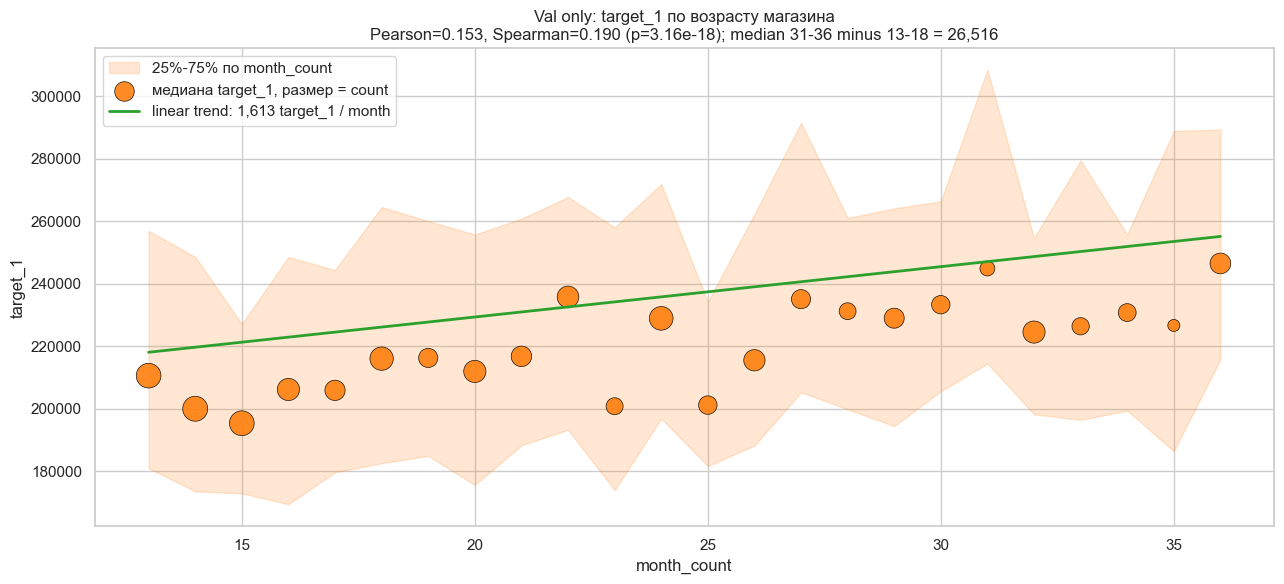

Monthly val summary:


,month_count,median,q25,q75,count
0,13,210579.060001,180927.381213,256942.813692,126
1,14,199984.327692,173543.547529,248596.258454,129
2,15,195343.379157,172895.516231,227144.602842,127
3,16,206156.499196,169403.060862,248563.524688,102
4,17,205876.010523,179658.601002,244400.869717,85
5,18,216030.147176,182524.600698,264557.398320,113
6,19,216259.569052,184891.988625,260073.172196,76
7,20,211933.487754,175576.914476,255766.076801,102
8,21,216773.168519,188279.273815,260837.633951,87
9,22,235800.269562,193240.423472,267759.225092,97


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import linregress, spearmanr

sns.set_theme(style='whitegrid', context='notebook')

DATA_DIR = Path('data')
val = pd.read_csv(DATA_DIR / 'val.csv')

feature = 'month_count'
target = 'target_1'

plot_df = val[[feature, target]].copy()
plot_df[target] = pd.to_numeric(plot_df[target], errors='coerce')
plot_df = plot_df.dropna(subset=[feature, target])

monthly = (
    plot_df
    .groupby(feature)[target]
    .agg(
        median='median',
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        count='size',
    )
    .reset_index()
    .sort_values(feature)
)

pearson = plot_df[feature].corr(plot_df[target], method='pearson')
spearman_corr, spearman_p = spearmanr(plot_df[feature], plot_df[target])
reg = linregress(plot_df[feature], plot_df[target])

x_line = np.linspace(plot_df[feature].min(), plot_df[feature].max(), 100)
y_line = reg.intercept + reg.slope * x_line

early = plot_df[plot_df[feature].between(13, 18)][target].median()
late = plot_df[plot_df[feature].between(31, 36)][target].median()
late_vs_early = late - early

plt.figure(figsize=(13, 6))
plt.fill_between(
    monthly[feature],
    monthly['q25'],
    monthly['q75'],
    alpha=0.18,
    color='#ff7f0e',
    label='25%-75% по month_count',
)
plt.scatter(
    monthly[feature],
    monthly['median'],
    s=monthly['count'] * 2.5,
    color='#ff7f0e',
    edgecolor='black',
    linewidth=0.5,
    alpha=0.9,
    label='медиана target_1, размер = count',
)
plt.plot(
    x_line,
    y_line,
    color='#2ca02c',
    linewidth=2,
    label=f'linear trend: {reg.slope:,.0f} target_1 / month',
)

plt.title(
    'Val only: target_1 по возрасту магазина\n'
    f'Pearson={pearson:.3f}, Spearman={spearman_corr:.3f} (p={spearman_p:.3g}); '
    f'median 31-36 minus 13-18 = {late_vs_early:,.0f}'
)
plt.xlabel('month_count')
plt.ylabel('target_1')
plt.legend()
plt.tight_layout()
plt.show()

print('Monthly val summary:')
display(monthly)


Мне кажется самым простым что можно сделать, это добавить в модель информацию о вот этом вот линейном тренде 

## Проверка selective bias по качеству локаций

Смотрим, менялись ли по возрасту магазина признаки `DIST_TO_ADM_CENTER` и `TRADING_PATCH_SCORE`. Если новые точки дальше от центра или имеют другой trading score, то эффект возраста может смешиваться с эффектом качества новых локаций.


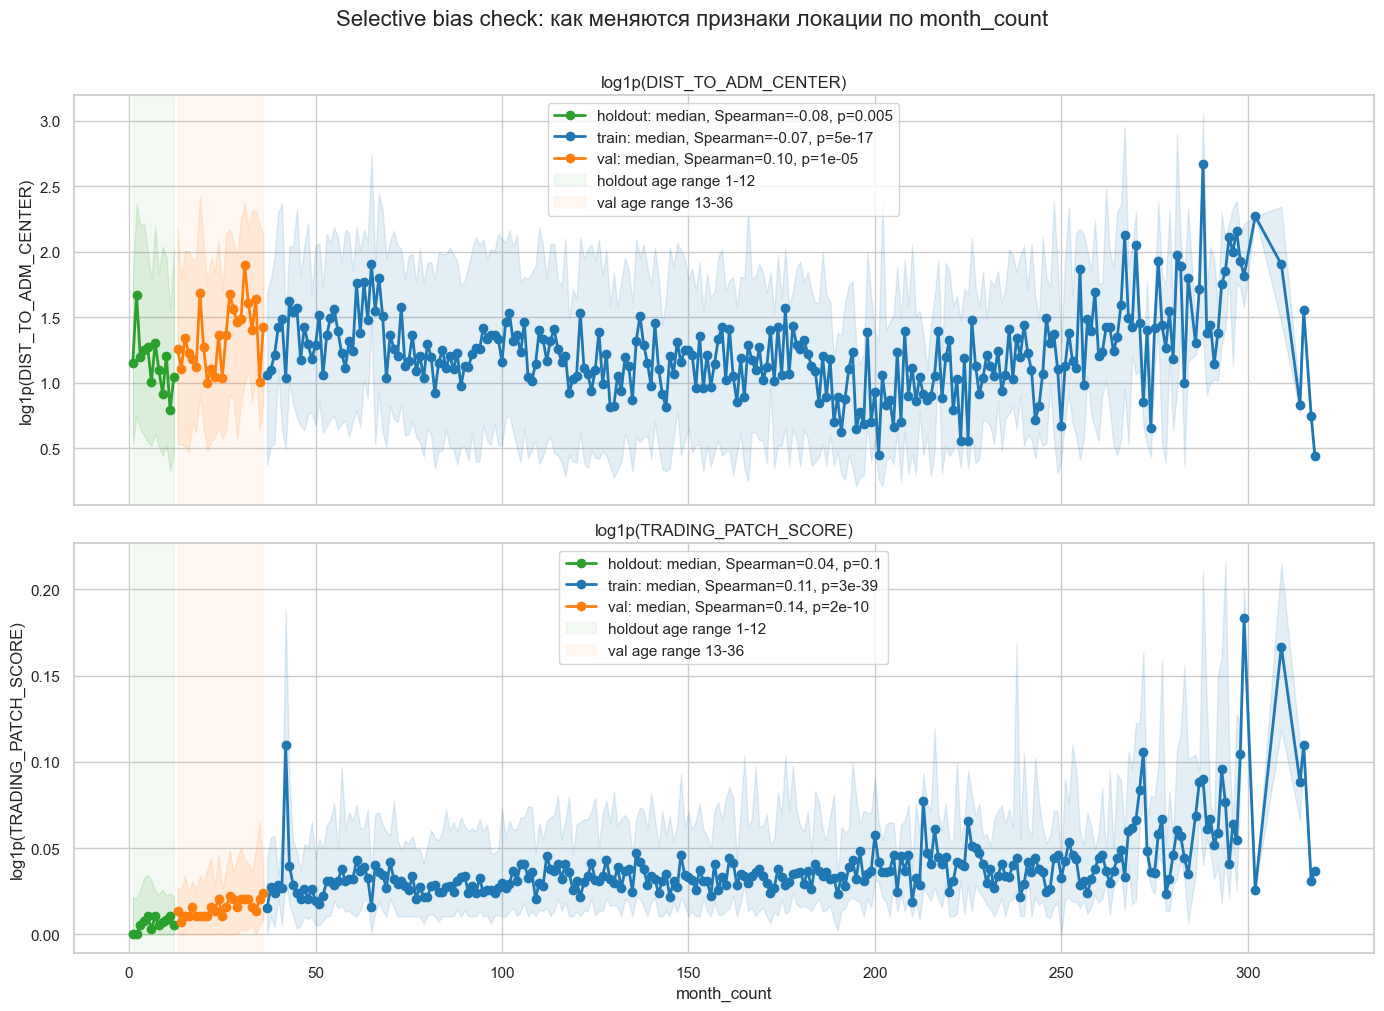

Median raw feature values by dataset and age group:


,dataset,age_group,DIST_TO_ADM_CENTER,TRADING_PATCH_SCORE
0,holdout,1-12 holdout,2.1942,0.0052
1,train,37-60 train,2.7731,0.0262
2,train,61-120 train,2.4456,0.0293
3,train,121+ train,2.0745,0.0356
4,val,13-36 val,2.8126,0.0136


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import spearmanr

sns.set_theme(style='whitegrid', context='notebook')

DATA_DIR = Path('data')
train = pd.read_csv(DATA_DIR / 'train.csv')
val = pd.read_csv(DATA_DIR / 'val.csv')
holdout = pd.read_csv(DATA_DIR / 'holdout.csv')

month_col = 'month_count'
features = ['DIST_TO_ADM_CENTER', 'TRADING_PATCH_SCORE']

parts = []
for dataset_name, df in [('train', train), ('val', val), ('holdout', holdout)]:
    part = df[[month_col] + features].copy()
    part['dataset'] = dataset_name
    parts.append(part)
location_df = pd.concat(parts, ignore_index=True)

for col in features:
    location_df[col] = pd.to_numeric(location_df[col], errors='coerce')
    # log1p мягко сжимает длинный хвост и спокойно работает с нулями.
    location_df[f'log1p_{col}'] = np.log1p(location_df[col].clip(lower=0))

plot_features = [f'log1p_{col}' for col in features]
pretty_names = {
    'log1p_DIST_TO_ADM_CENTER': 'log1p(DIST_TO_ADM_CENTER)',
    'log1p_TRADING_PATCH_SCORE': 'log1p(TRADING_PATCH_SCORE)',
}
palette = {'train': '#1f77b4', 'val': '#ff7f0e', 'holdout': '#2ca02c'}

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Selective bias check: как меняются признаки локации по month_count', fontsize=16, y=1.01)

for ax, feature in zip(axes, plot_features):
    monthly = (
        location_df
        .dropna(subset=[month_col, feature])
        .groupby(['dataset', month_col])[feature]
        .agg(
            median='median',
            q25=lambda x: x.quantile(0.25),
            q75=lambda x: x.quantile(0.75),
            count='size',
        )
        .reset_index()
        .sort_values(month_col)
    )

    legend_labels = []
    for dataset_name, part in monthly.groupby('dataset'):
        raw_part = location_df.loc[location_df['dataset'].eq(dataset_name), [month_col, feature]].dropna()
        if raw_part[month_col].nunique() > 1:
            corr, p_value = spearmanr(raw_part[month_col], raw_part[feature])
            trend_label = f'{dataset_name}: median, Spearman={corr:.2f}, p={p_value:.1g}'
        else:
            trend_label = f'{dataset_name}: median'
        legend_labels.append(trend_label)

        color = palette[dataset_name]
        ax.fill_between(part[month_col], part['q25'], part['q75'], color=color, alpha=0.12)
        ax.plot(
            part[month_col],
            part['median'],
            marker='o',
            linewidth=2,
            color=color,
            label=trend_label,
        )

    ax.axvspan(1, 12, color=palette['holdout'], alpha=0.06, label='holdout age range 1-12')
    ax.axvspan(13, 36, color=palette['val'], alpha=0.05, label='val age range 13-36')
    ax.set_title(pretty_names[feature])
    ax.set_ylabel(pretty_names[feature])
    ax.legend(loc='best')

axes[-1].set_xlabel('month_count')
plt.tight_layout()
plt.show()

summary = (
    location_df
    .assign(age_group=pd.cut(
        location_df[month_col],
        bins=[0, 12, 36, 60, 120, 10_000],
        labels=['1-12 holdout', '13-36 val', '37-60 train', '61-120 train', '121+ train'],
    ))
    .groupby(['dataset', 'age_group'], observed=True)[features]
    .median()
    .round(4)
    .reset_index()
)

print('Median raw feature values by dataset and age group:')
display(summary)


## `TOTAL_RANK_COMPS_CANNIBALS`

Смотрим дрейф важного признака `TOTAL_RANK_COMPS_CANNIBALS` и его связь с `target_1`. По названию это похоже на ранг/позицию открытия точки среди конкурентов или каннибализирующих объектов в локации: чем значение меньше, тем потенциально раньше/лучше позиция; чем больше, тем больше уже занятых похожих точек вокруг. Это гипотеза, ее стоит сверить с описанием признаков, если оно появится.


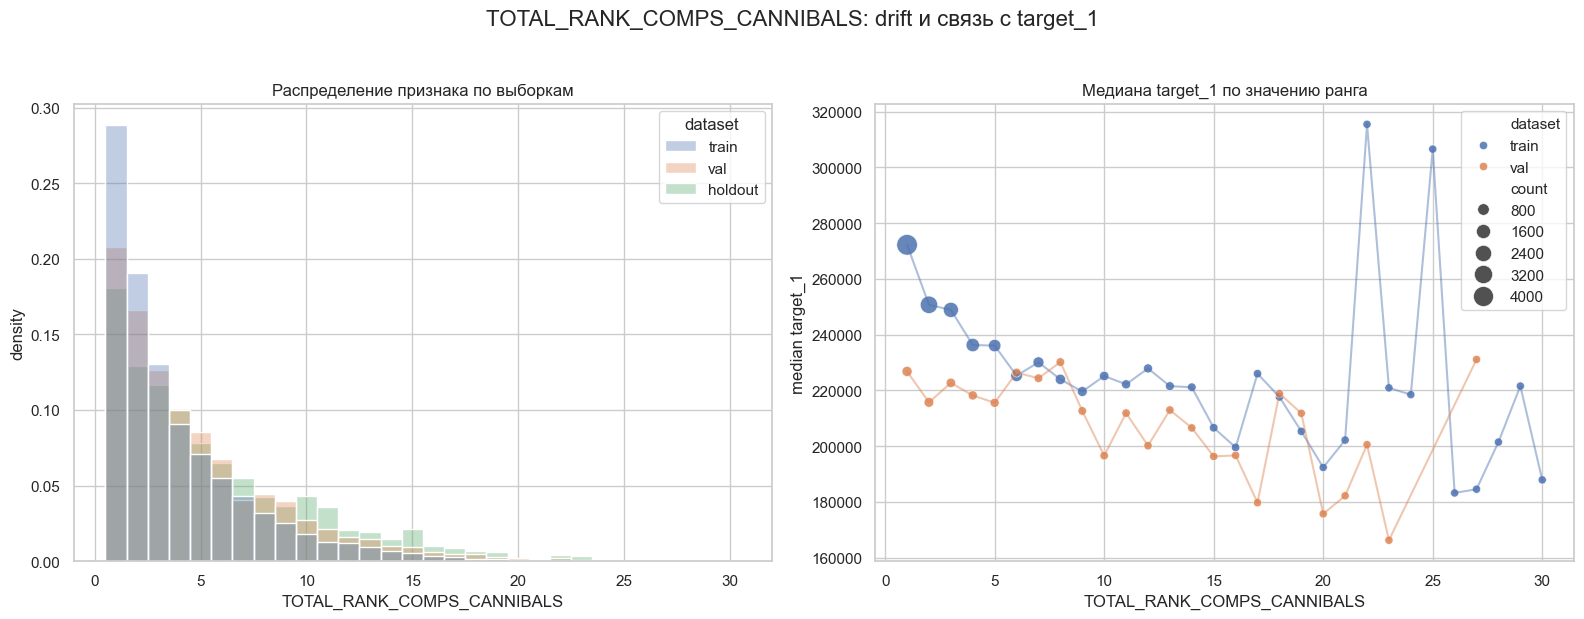

Distribution summary:


,count,nunique,min,median,mean,max
dataset,,,,,,
holdout,1322,26,1.0,4.0,5.666,27.0
train,15109,30,1.0,3.0,3.849,30.0
val,2067,24,1.0,3.0,4.756,27.0


Top values by dataset, share:

holdout


,TOTAL_RANK_COMPS_CANNIBALS,share
0,1.0,0.1808
1,2.0,0.1293
2,3.0,0.1165
3,4.0,0.0998
4,5.0,0.0779
5,6.0,0.0651
6,7.0,0.0552
7,8.0,0.0424
8,9.0,0.0363
9,10.0,0.0431



train


,TOTAL_RANK_COMPS_CANNIBALS,share
0,1.0,0.2884
1,2.0,0.1904
2,3.0,0.1305
3,4.0,0.0904
4,5.0,0.0708
5,6.0,0.0553
6,7.0,0.0428
7,8.0,0.0320
8,9.0,0.0250
9,10.0,0.0179



val


,TOTAL_RANK_COMPS_CANNIBALS,share
0,1.0,0.2075
1,2.0,0.1659
2,3.0,0.1268
3,4.0,0.1001
4,5.0,0.0851
5,6.0,0.0672
6,7.0,0.0406
7,8.0,0.0445
8,9.0,0.0397
9,10.0,0.0271


Correlation with target_1 where target is available:
train: Spearman=-0.251, p=4.55e-216
val: Spearman=-0.092, p=2.57e-05


In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import spearmanr

sns.set_theme(style='whitegrid', context='notebook')

DATA_DIR = Path('data')
train = pd.read_csv(DATA_DIR / 'train.csv')
val = pd.read_csv(DATA_DIR / 'val.csv')
holdout = pd.read_csv(DATA_DIR / 'holdout.csv')

feature = 'TOTAL_RANK_COMPS_CANNIBALS'
target = 'target_1'

parts = []
for dataset_name, df in [('train', train), ('val', val), ('holdout', holdout)]:
    cols = ['month_count', feature] + ([target] if target in df.columns else [])
    part = df[cols].copy()
    part['dataset'] = dataset_name
    if target not in part.columns:
        part[target] = pd.NA
    parts.append(part)

rank_df = pd.concat(parts, ignore_index=True)
rank_df[feature] = pd.to_numeric(rank_df[feature], errors='coerce')
rank_df[target] = pd.to_numeric(rank_df[target], errors='coerce')
rank_df = rank_df.dropna(subset=[feature])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('TOTAL_RANK_COMPS_CANNIBALS: drift и связь с target_1', fontsize=16, y=1.03)

sns.histplot(
    data=rank_df,
    x=feature,
    hue='dataset',
    stat='density',
    common_norm=False,
    discrete=True,
    multiple='layer',
    alpha=0.35,
    ax=axes[0],
)
axes[0].set_title('Распределение признака по выборкам')
axes[0].set_xlabel(feature)
axes[0].set_ylabel('density')

rank_target = rank_df[rank_df['dataset'].isin(['train', 'val'])].dropna(subset=[target]).copy()
rank_summary = (
    rank_target
    .groupby(['dataset', feature], as_index=False)
    .agg(
        median_target_1=(target, 'median'),
        count=(target, 'size'),
    )
)

sns.scatterplot(
    data=rank_summary,
    x=feature,
    y='median_target_1',
    hue='dataset',
    size='count',
    sizes=(35, 220),
    alpha=0.85,
    ax=axes[1],
)
sns.lineplot(
    data=rank_summary,
    x=feature,
    y='median_target_1',
    hue='dataset',
    estimator=None,
    legend=False,
    alpha=0.45,
    ax=axes[1],
)
axes[1].set_title('Медиана target_1 по значению ранга')
axes[1].set_xlabel(feature)
axes[1].set_ylabel('median target_1')

plt.tight_layout()
plt.show()

print('Distribution summary:')
display(
    rank_df
    .groupby('dataset')[feature]
    .agg(['count', 'nunique', 'min', 'median', 'mean', 'max'])
    .round(3)
)

print('Top values by dataset, share:')
for dataset_name, part in rank_df.groupby('dataset'):
    print(f'\n{dataset_name}')
    display(
        part[feature]
        .value_counts(normalize=True)
        .sort_index()
        .rename('share')
        .reset_index()
        .rename(columns={'index': feature})
        .assign(share=lambda x: x['share'].round(4))
    )

print('Correlation with target_1 where target is available:')
for dataset_name, part in rank_target.groupby('dataset'):
    corr, p_value = spearmanr(part[feature], part[target], nan_policy='omit')
    print(f'{dataset_name}: Spearman={corr:.3f}, p={p_value:.3g}')


## `HuffFamilies` по времени

Смотрим, как `HuffFamilies` меняется по `month_count` в train/val/holdout, и есть ли связь с `target_1`.


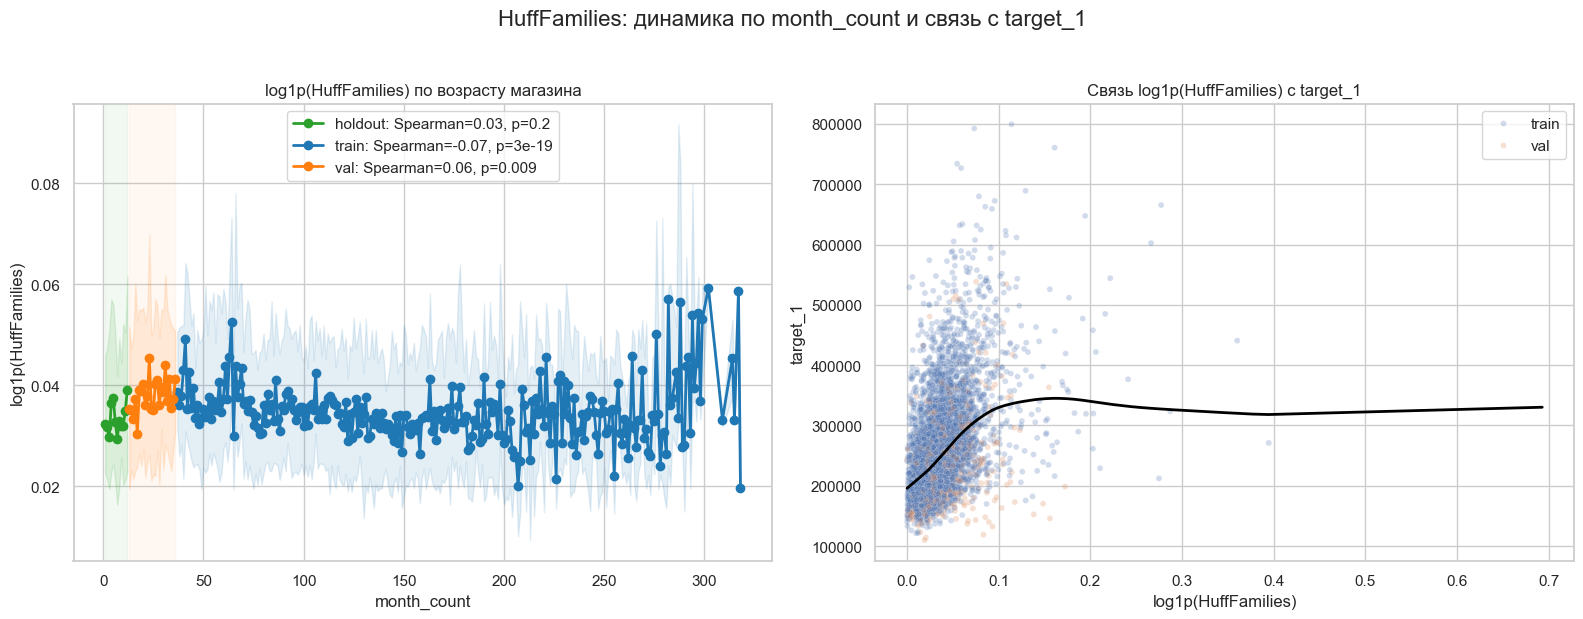

Median HuffFamilies by dataset:


,count,min,median,mean,max
dataset,,,,,
holdout,1322,0.00009,0.03362,0.04226,0.54568
train,15109,0.00000,0.03485,0.03990,1.00000
val,2068,-0.00001,0.03817,0.04488,0.32032


Spearman correlation with target_1:
train: Spearman=0.482, p=0
val: Spearman=0.387, p=7.2e-75


In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import spearmanr

sns.set_theme(style='whitegrid', context='notebook')

DATA_DIR = Path('data')
train = pd.read_csv(DATA_DIR / 'train.csv')
val = pd.read_csv(DATA_DIR / 'val.csv')
holdout = pd.read_csv(DATA_DIR / 'holdout.csv')

month_col = 'month_count'
feature = 'HuffFamilies'
target = 'target_1'

parts = []
for dataset_name, df in [('train', train), ('val', val), ('holdout', holdout)]:
    cols = [month_col, feature] + ([target] if target in df.columns else [])
    part = df[cols].copy()
    part['dataset'] = dataset_name
    if target not in part.columns:
        part[target] = pd.NA
    parts.append(part)

huff_df = pd.concat(parts, ignore_index=True)
huff_df[feature] = pd.to_numeric(huff_df[feature], errors='coerce')
huff_df[target] = pd.to_numeric(huff_df[target], errors='coerce')
huff_df[f'log1p_{feature}'] = np.log1p(huff_df[feature].clip(lower=0))

plot_feature = f'log1p_{feature}'
palette = {'train': '#1f77b4', 'val': '#ff7f0e', 'holdout': '#2ca02c'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('HuffFamilies: динамика по month_count и связь с target_1', fontsize=16, y=1.03)

monthly = (
    huff_df
    .dropna(subset=[month_col, plot_feature])
    .groupby(['dataset', month_col])[plot_feature]
    .agg(
        median='median',
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        count='size',
    )
    .reset_index()
    .sort_values(month_col)
)

for dataset_name, part in monthly.groupby('dataset'):
    raw_part = huff_df.loc[huff_df['dataset'].eq(dataset_name), [month_col, plot_feature]].dropna()
    corr, p_value = spearmanr(raw_part[month_col], raw_part[plot_feature])
    color = palette[dataset_name]
    axes[0].fill_between(part[month_col], part['q25'], part['q75'], color=color, alpha=0.12)
    axes[0].plot(
        part[month_col],
        part['median'],
        marker='o',
        linewidth=2,
        color=color,
        label=f'{dataset_name}: Spearman={corr:.2f}, p={p_value:.1g}',
    )

axes[0].axvspan(1, 12, color=palette['holdout'], alpha=0.06)
axes[0].axvspan(13, 36, color=palette['val'], alpha=0.05)
axes[0].set_title('log1p(HuffFamilies) по возрасту магазина')
axes[0].set_xlabel(month_col)
axes[0].set_ylabel('log1p(HuffFamilies)')
axes[0].legend(loc='best')

huff_target = huff_df[huff_df['dataset'].isin(['train', 'val'])].dropna(subset=[plot_feature, target]).copy()
sns.scatterplot(
    data=huff_target.sample(min(len(huff_target), 5000), random_state=42),
    x=plot_feature,
    y=target,
    hue='dataset',
    alpha=0.25,
    s=18,
    ax=axes[1],
)
sns.regplot(
    data=huff_target,
    x=plot_feature,
    y=target,
    scatter=False,
    lowess=True,
    color='black',
    line_kws={'linewidth': 2, 'label': 'LOWESS trend'},
    ax=axes[1],
)
axes[1].set_title('Связь log1p(HuffFamilies) с target_1')
axes[1].set_xlabel('log1p(HuffFamilies)')
axes[1].set_ylabel('target_1')
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()

print('Median HuffFamilies by dataset:')
display(huff_df.groupby('dataset')[feature].agg(['count', 'min', 'median', 'mean', 'max']).round(5))

print('Spearman correlation with target_1:')
for dataset_name, part in huff_target.groupby('dataset'):
    corr, p_value = spearmanr(part[feature], part[target], nan_policy='omit')
    print(f'{dataset_name}: Spearman={corr:.3f}, p={p_value:.3g}')


In [44]:
train['REGION'].unique()

array(['Южный округ', 'Кавказский округ', 'Волжский округ',
       'Московский округ', 'Черноземный округ', 'Западный округ',
       'Северо-Западный округ', 'Приволжский округ',
       'Южно-Уральский округ', 'Камский округ', 'Уральский округ',
       'Сибирский округ'], dtype=object)

In [ ]:

train['CITY'].unique()

array(['Армавир', 'Новороссийск Запад', 'Ростов-на-Дону Запад',
       'Волгоград Восток', 'Волгодонск', 'Астрахань', 'Краснодар Восток',
       'Волгоград Запад', 'Краснодар Запад', 'Новороссийск Восток',
       'Саратов Запад', 'Ростов-на-Дону Восток', 'Пятигорск',
       'Саратов Восток', 'Каневская', 'Сочи', 'Ставрополь', 'Тольятти',
       'Владикавказ', 'Шахты', 'Пенза', 'Москва 2', 'Воронеж Юг',
       'Липецк', 'Москва 1', 'Москва 6', 'Орел', 'Москва 3',
       'Воронеж Север', 'Белгород Запад', 'Курск', 'Белгород Восток',
       'Санкт-Петербург Юг', 'Самара Запад', 'Самара Восток',
       'Санкт-Петербург Север', 'Санкт-Петербург Центр',
       'Ярославль Восток', 'Ульяновск', 'Тамбов', 'Ярославль Запад',
       'Калуга', 'Смоленск', 'Оренбург', 'Москва 4',
       'Санкт-Петербург Восток', 'Уфа Восток', 'Брянск', 'Москва 5',
       'Тула', 'Орск', 'Уфа Запад', 'Казань Запад', 'Псков',
       'Казань Восток', 'Иваново', 'Владимир', 'Тверь', 'Стерлитамак',
       'Челябинск Вос

## Распределение `CITY` в train

Смотрим, какие города чаще всего встречаются в train и насколько длинный хвост редких городов.


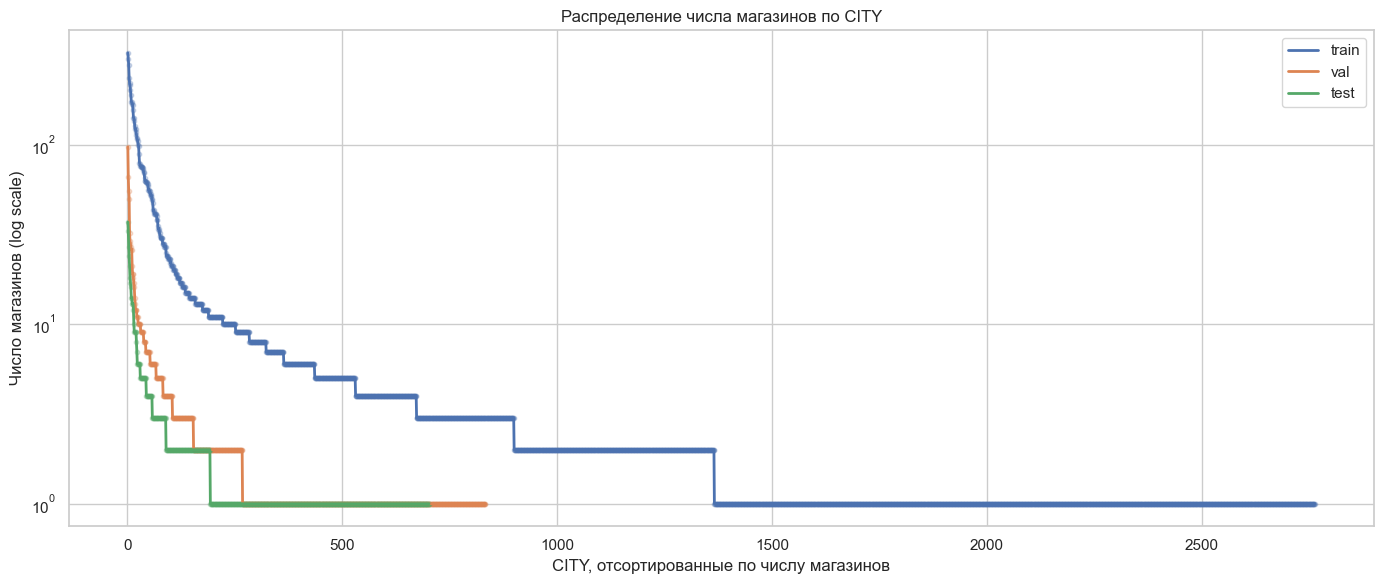

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', context='notebook')

DATA_DIR = Path('data')
train = pd.read_csv(DATA_DIR / 'train.csv')
val = pd.read_csv(DATA_DIR / 'val.csv')
test = pd.read_csv(DATA_DIR / 'holdout.csv')

def plot_category_count_distribution(datasets, column, log_y=True):
    fig, ax = plt.subplots(figsize=(14, 6))

    for dataset_name, df in datasets.items():
        counts = df[column].value_counts(dropna=False).reset_index()
        counts.columns = [column, 'count']
        counts['category_rank'] = range(1, len(counts) + 1)

        sns.lineplot(
            data=counts,
            x='category_rank',
            y='count',
            linewidth=2,
            label=dataset_name,
            ax=ax,
        )
        ax.scatter(counts['category_rank'], counts['count'], s=10, alpha=0.25)

    if log_y:
        ax.set_yscale('log')

    ax.set_title(f'Распределение числа магазинов по {column}')
    ax.set_xlabel(f'{column}, отсортированные по числу магазинов')
    ax.set_ylabel('Число магазинов' + (' (log scale)' if log_y else ''))
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_category_count_distribution(
    datasets={
        'train': train,
        'val': val,
        'test': test,
    },
    column='CITY',
)


Есть очень много городов, в которых всего лишь 1 магазин. Надо создать качественыне локационные признаки, чтобы такие города классифицировались корректно. Без такого модель наверно потеряет очень много качества

In [66]:
city_freq = train["CITY"].value_counts()

rare = city_freq[city_freq < 5].index

train["CITY_rare"] = train["CITY"].where(~train["CITY"].isin(rare), "RARE")

In [68]:
train["CITY_rare"].nunique()

531

## Географические count-фичи и rare grouping для `CITY`

Фитим счетчики на train, затем одинаково трансформируем train/val/test. Сырой `CITY` дальше лучше не использовать: вместо него есть `CITY_grouped`, где редкие города заменены на `RARE`, и `log1p_CITY_count`.


Rare city threshold: < 5 объектов в train
Original unique CITY in train: 2763
Frequent CITY kept: 530
Rows mapped to RARE in train: 3579
Rows mapped to RARE in val: 598
Rows mapped to RARE in test: 501


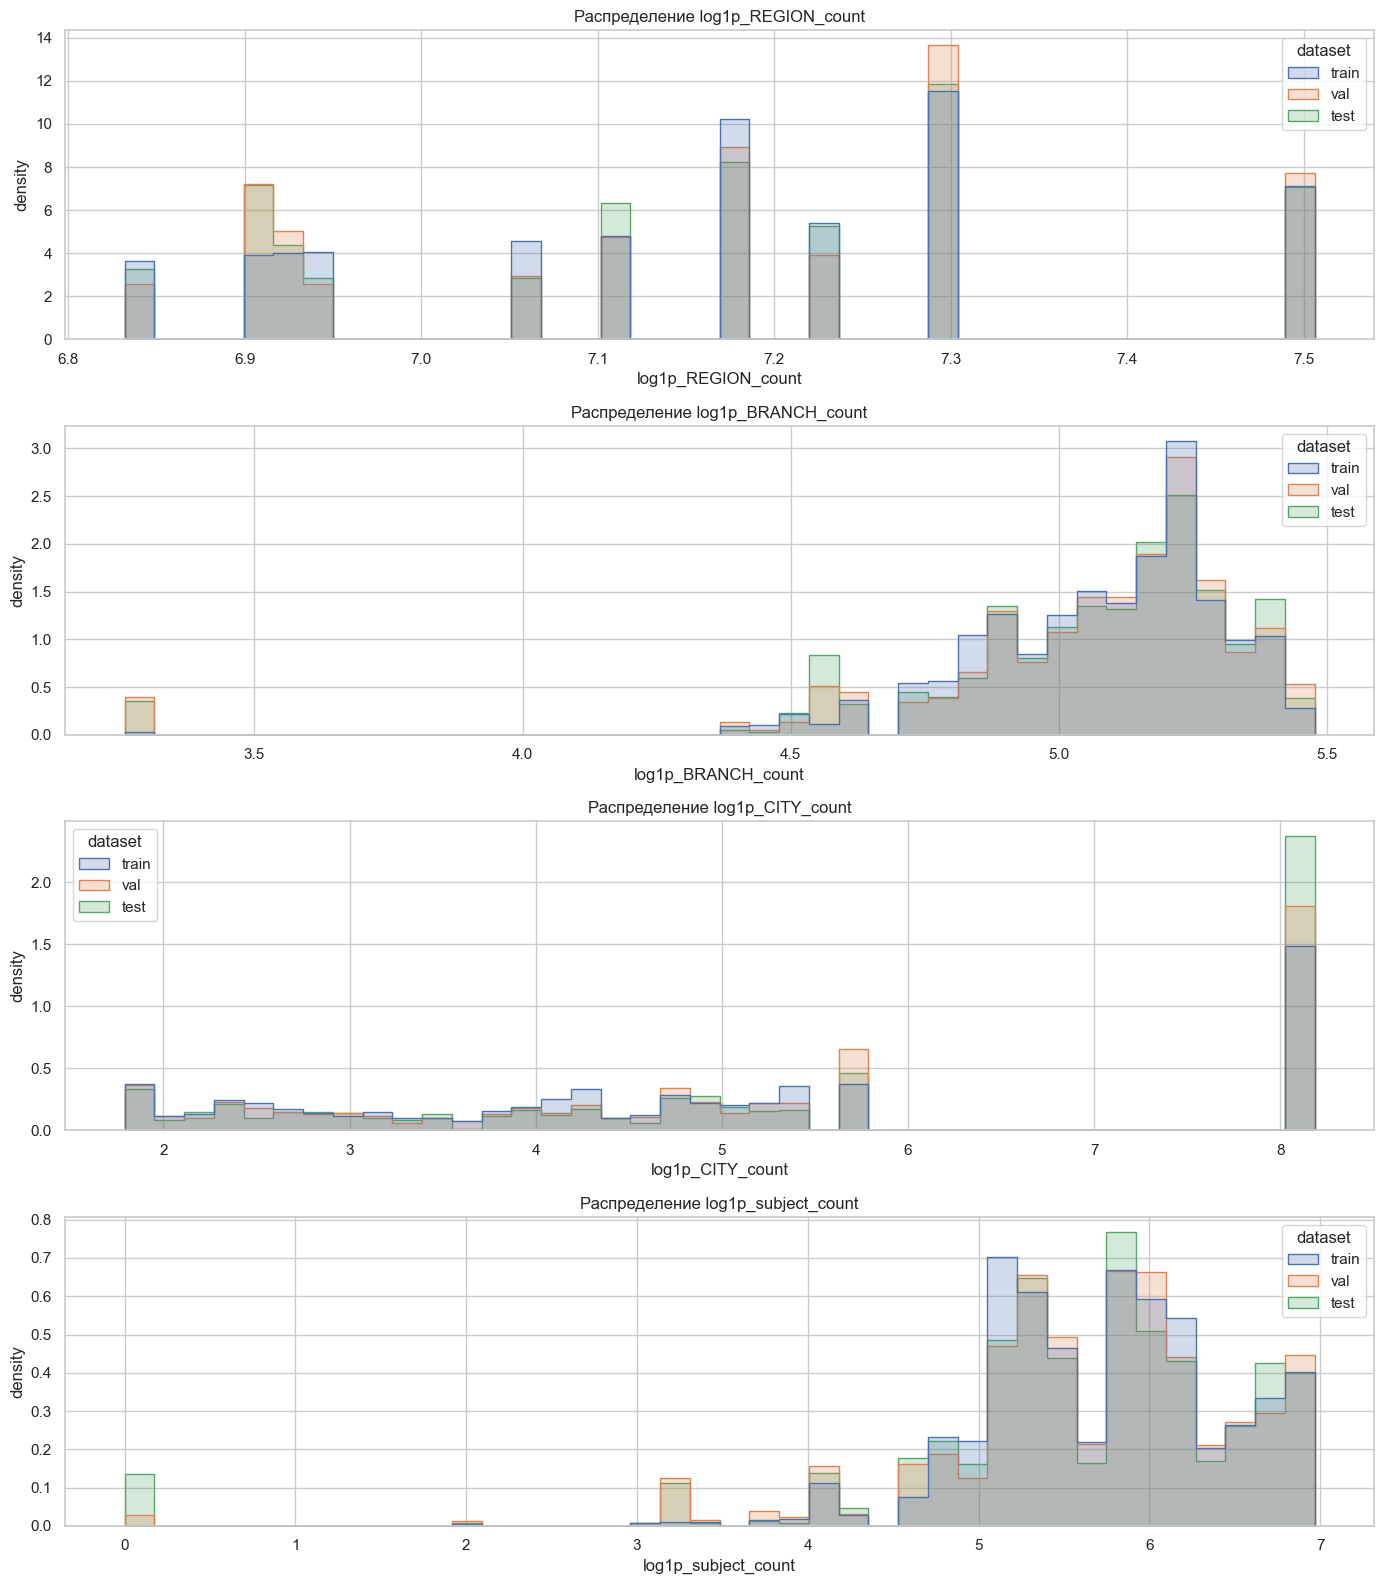

,dataset,REGION_count_median,REGION_count_mean,BRANCH_count_median,BRANCH_count_mean,CITY_count_median,CITY_count_mean,subject_count_median,subject_count_mean
0,train,1302.0,1306.29,167.0,164.45,107.0,916.87,346.0,389.36
1,val,1305.0,1311.22,168.0,163.26,141.0,1108.97,346.0,383.78
2,test,1302.0,1297.60,167.0,162.41,172.0,1415.99,336.0,382.67


In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', context='notebook')

DATA_DIR = Path('data')
train = pd.read_csv(DATA_DIR / 'train.csv')
val = pd.read_csv(DATA_DIR / 'val.csv')
test = pd.read_csv(DATA_DIR / 'holdout.csv')

GEO_COLUMNS = ['REGION', 'BRANCH', 'CITY', 'subject']

def fit_geo_count_features(train_df, rare_city_threshold=5):
    city_counts = train_df['CITY'].value_counts(dropna=False)
    frequent_cities = set(city_counts[city_counts >= rare_city_threshold].index)
    rare_count = int(city_counts[city_counts < rare_city_threshold].sum())
    city_group_counts = {
        city: int(count)
        for city, count in city_counts.items()
        if city in frequent_cities
    }
    city_group_counts['RARE'] = rare_count

    mappings = {
        'rare_city_threshold': rare_city_threshold,
        'frequent_cities': frequent_cities,
        'rare_city_count': rare_count,
        'city_group_counts': city_group_counts,
        'counts': {
            'REGION': train_df['REGION'].value_counts(dropna=False).to_dict(),
            'BRANCH': train_df['BRANCH'].value_counts(dropna=False).to_dict(),
            'subject': train_df['subject'].value_counts(dropna=False).to_dict(),
        },
    }
    return mappings


def add_geo_count_features(df, mappings):
    result = df.copy()

    for column in ['REGION', 'BRANCH', 'subject']:
        count_col = f'{column}_count'
        result[count_col] = result[column].map(mappings['counts'][column]).fillna(0).astype(int)
        result[f'log1p_{count_col}'] = np.log1p(result[count_col])

    result['CITY_grouped'] = result['CITY'].where(
        result['CITY'].isin(mappings['frequent_cities']),
        'RARE',
    )

    result['CITY_count'] = (
        result['CITY_grouped']
        .map(mappings['city_group_counts'])
        .fillna(mappings['rare_city_count'])
        .astype(int)
    )
    result['log1p_CITY_count'] = np.log1p(result['CITY_count'])

    return result


def plot_geo_count_features(datasets, features):
    fig, axes = plt.subplots(len(features), 1, figsize=(14, 4 * len(features)), sharex=False)
    if len(features) == 1:
        axes = [axes]

    for ax, feature in zip(axes, features):
        plot_parts = []
        for dataset_name, df in datasets.items():
            part = df[[feature]].copy()
            part['dataset'] = dataset_name
            plot_parts.append(part)
        plot_df = pd.concat(plot_parts, ignore_index=True)

        sns.histplot(
            data=plot_df,
            x=feature,
            hue='dataset',
            stat='density',
            common_norm=False,
            element='step',
            bins=40,
            ax=ax,
        )
        ax.set_title(f'Распределение {feature}')
        ax.set_ylabel('density')

    plt.tight_layout()
    plt.show()


geo_mappings = fit_geo_count_features(train, rare_city_threshold=5)
train_geo = add_geo_count_features(train, geo_mappings)
val_geo = add_geo_count_features(val, geo_mappings)
test_geo = add_geo_count_features(test, geo_mappings)

print(f"Rare city threshold: < {geo_mappings['rare_city_threshold']} объектов в train")
print(f"Original unique CITY in train: {train['CITY'].nunique(dropna=False)}")
print(f"Frequent CITY kept: {len(geo_mappings['frequent_cities'])}")
print(f"Rows mapped to RARE in train: {(train_geo['CITY_grouped'] == 'RARE').sum()}")
print(f"Rows mapped to RARE in val: {(val_geo['CITY_grouped'] == 'RARE').sum()}")
print(f"Rows mapped to RARE in test: {(test_geo['CITY_grouped'] == 'RARE').sum()}")

plot_geo_count_features(
    datasets={
        'train': train_geo,
        'val': val_geo,
        'test': test_geo,
    },
    features=[
        'log1p_REGION_count',
        'log1p_BRANCH_count',
        'log1p_CITY_count',
        'log1p_subject_count',
    ],
)

summary_features = ['REGION_count', 'BRANCH_count', 'CITY_count', 'subject_count']
summary = []
for dataset_name, df in [('train', train_geo), ('val', val_geo), ('test', test_geo)]:
    row = {'dataset': dataset_name}
    for feature in summary_features:
        row[f'{feature}_median'] = df[feature].median()
        row[f'{feature}_mean'] = df[feature].mean()
    summary.append(row)

display(pd.DataFrame(summary).round(2))


In [ ]:
train['SUBFRMT'].unique()

array([2, 1])

## Фича квартала возраста магазина

`month_count` переводим в порядковый квартал возраста: `1-3 -> 1`, `4-6 -> 2`, `10-12 -> 4`, `13-15 -> 5` и так далее без циклического сброса после 4.


In [ ]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path('data')
train = pd.read_csv(DATA_DIR / 'train.csv')
val = pd.read_csv(DATA_DIR / 'val.csv')
test = pd.read_csv(DATA_DIR / 'holdout.csv')

def add_age_quarter_feature(df, month_col='month_count', new_col='age_quarter'):
    result = df.copy()
    result[new_col] = ((result[month_col] - 1) // 3 + 1).astype(int)
    return result

train_q = add_age_quarter_feature(train)
val_q = add_age_quarter_feature(val)
test_q = add_age_quarter_feature(test)

for name, df in [('train', train_q), ('val', val_q), ('test', test_q)]:
    print(f'{name}: month_count {df["month_count"].min()}..{df["month_count"].max()}, '
          f'age_quarter {df["age_quarter"].min()}..{df["age_quarter"].max()}')

display(
    pd.concat([
        train_q[['month_count', 'age_quarter']].assign(dataset='train'),
        val_q[['month_count', 'age_quarter']].assign(dataset='val'),
        test_q[['month_count', 'age_quarter']].assign(dataset='test'),
    ])
    .drop_duplicates()
    .sort_values(['month_count', 'dataset'])
    .head(50)
)


## `target_2` по `SUBFRMT` в train

Сравниваем нормированные распределения `target_2` для двух значений `SUBFRMT`, чтобы дисбаланс размеров групп не влиял на визуализацию.


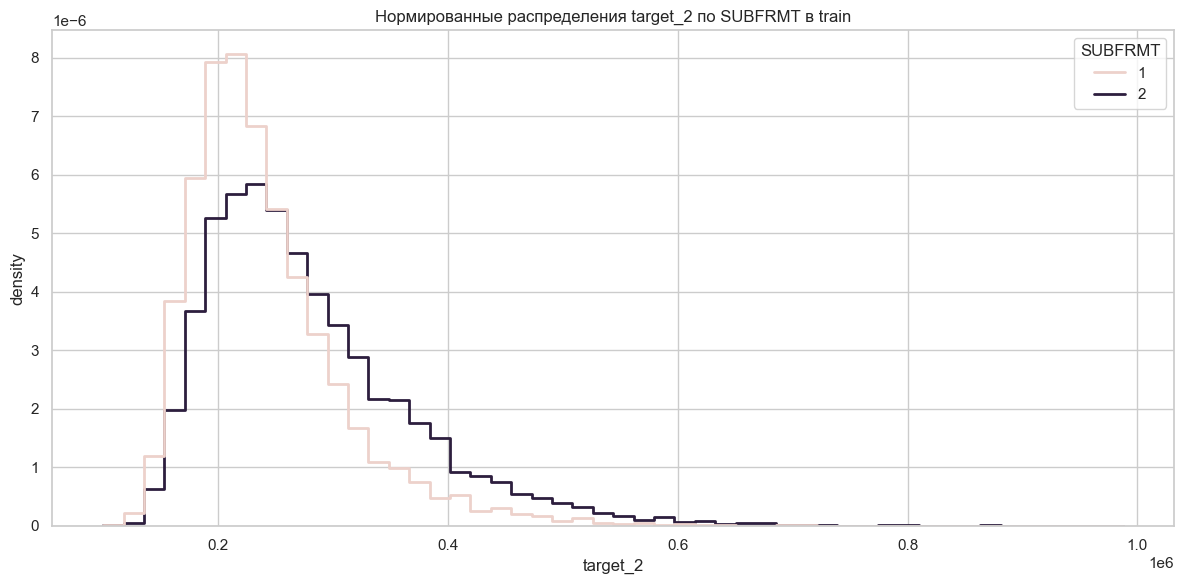

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', context='notebook')

train = pd.read_csv(Path('data') / 'train.csv')

plot_df = train[['SUBFRMT', 'target_2']].copy()
plot_df['target_2'] = pd.to_numeric(plot_df['target_2'], errors='coerce')
plot_df = plot_df.dropna(subset=['SUBFRMT', 'target_2'])

plt.figure(figsize=(12, 6))
sns.histplot(
    data=plot_df,
    x='target_2',
    hue='SUBFRMT',
    stat='density',
    common_norm=False,
    bins=50,
    element='step',
    fill=False,
    linewidth=2,
)
plt.title('Нормированные распределения target_2 по SUBFRMT в train')
plt.xlabel('target_2')
plt.ylabel('density')
plt.tight_layout()
plt.show()


In [79]:
train['SUBFRMT'].value_counts()

SUBFRMT
2    8995
1    6114
Name: count, dtype: int64

## Эксперименты с `SUBFRMT` drift

Три простых CatBoost-эксперимента для проверки гипотезы, что `SUBFRMT == 2` тянет train target вправо, хотя в val/test почти/совсем нет второго типа. Оцениваем MAPE на `val`, исключая 20 объектов `SUBFRMT == 2`.


In [90]:
import numpy as np
import pandas as pd
from pathlib import Path

try:
    from catboost import CatBoostRegressor
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError('CatBoost is not installed. Install it with: pip install catboost') from exc

DATA_DIR = Path('data')
train = pd.read_csv(DATA_DIR / 'train.csv')
val = pd.read_csv(DATA_DIR / 'val.csv')

TARGET = 'target_2'
DROP_COLUMNS = ['ID', 'target_1', 'target_2']
RANDOM_SEED = 42

feature_cols = [col for col in train.columns if col not in DROP_COLUMNS]
cat_cols = train[feature_cols].select_dtypes(include='object').columns.tolist()
cat_cols = cat_cols + ['SUBFRMT']
cat_cols = [col for col in cat_cols if col in feature_cols]


def prepare_xy(df, target_col=TARGET):
    data = df.copy()
    data[target_col] = pd.to_numeric(data[target_col], errors='coerce')
    data = data.dropna(subset=[target_col])

    X = data[feature_cols].copy()
    y = data[target_col].astype(float)

    for col in cat_cols:
        X[col] = X[col].astype('string').fillna('NA')

    return X, y


def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def fit_catboost(X_train, y_train):
    model = CatBoostRegressor(
        loss_function='MAE',
        eval_metric='MAPE',
        iterations=800,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=5,
        random_seed=RANDOM_SEED,
        verbose=False,
        allow_writing_files=False,
    )
    model.fit(X_train, y_train, cat_features=cat_cols)
    return model


def run_experiment(name, train_df, target_shift_for_subfrmt2=False):
    exp_train = train_df.copy()

    if target_shift_for_subfrmt2:
        mean_type_1 = pd.to_numeric(
            exp_train.loc[exp_train['SUBFRMT'].eq(1), TARGET],
            errors='coerce',
        ).mean()
        mean_type_2 = pd.to_numeric(
            exp_train.loc[exp_train['SUBFRMT'].eq(2), TARGET],
            errors='coerce',
        ).mean()
        shift = mean_type_2 - mean_type_1
        exp_train[TARGET] = pd.to_numeric(exp_train[TARGET], errors='coerce')
        exp_train.loc[exp_train['SUBFRMT'].eq(2), TARGET] -= shift
    else:
        shift = 0.0

    X_train, y_train = prepare_xy(exp_train)
    model = fit_catboost(X_train, y_train)
    pred = model.predict(X_val)

    return {
        'experiment': name,
        'train_rows': len(X_train),
        'subfrmt_1_rows': int((exp_train.loc[X_train.index, 'SUBFRMT'] == 1).sum()),
        'subfrmt_2_rows': int((exp_train.loc[X_train.index, 'SUBFRMT'] == 2).sum()),
        'target_shift_for_subfrmt2': shift,
        'val_mape_percent': mape(y_val, pred),
    }

# Честный eval под test-домен: в val оставляем только SUBFRMT == 1.
val_eval = val[val['SUBFRMT'].eq(1)].copy()
X_val, y_val = prepare_xy(val_eval)

print(f'Eval rows, val SUBFRMT == 1: {len(X_val)}')
print('Train SUBFRMT counts:')
display(train['SUBFRMT'].value_counts().sort_index().rename('count').to_frame())
print('Val SUBFRMT counts:')
display(val['SUBFRMT'].value_counts().sort_index().rename('count').to_frame())

results = []

# 1. Все train-данные как есть.
results.append(run_experiment(
    name='all_train_raw_target',
    train_df=train,
    target_shift_for_subfrmt2=False,
))

# 2. Все train-данные, но target_2 для SUBFRMT == 2 сдвигаем влево на разницу средних.
results.append(run_experiment(
    name='all_train_shift_subfrmt2_target_by_mean_diff',
    train_df=train,
    target_shift_for_subfrmt2=True,
))

# 3. Только train-данные SUBFRMT == 1.
results.append(run_experiment(
    name='only_subfrmt1_train',
    train_df=train[train['SUBFRMT'].eq(1)].copy(),
    target_shift_for_subfrmt2=False,
))

results_df = pd.DataFrame(results).sort_values('val_mape_percent')
display(results_df)


Eval rows, val SUBFRMT == 1: 2048
Train SUBFRMT counts:


,count
SUBFRMT,
1,6114
2,8995


Val SUBFRMT counts:


,count
SUBFRMT,
1,2048
2,20


,experiment,train_rows,subfrmt_1_rows,subfrmt_2_rows,target_shift_for_subfrmt2,val_mape_percent
0,all_train_raw_target,15109,6114,8995,0.000000,17.511440
1,all_train_shift_subfrmt2_target_by_mean_diff,15109,6114,8995,37742.609419,17.861034
2,only_subfrmt1_train,6114,6114,0,0.000000,18.647283


## `month_count`: train/val target_1 и test predictions

Тот же график по возрасту магазина, но с добавленной линией test из `submissions/best.csv`. Для test используется `PREDICT`, потому что настоящего таргета в holdout нет.


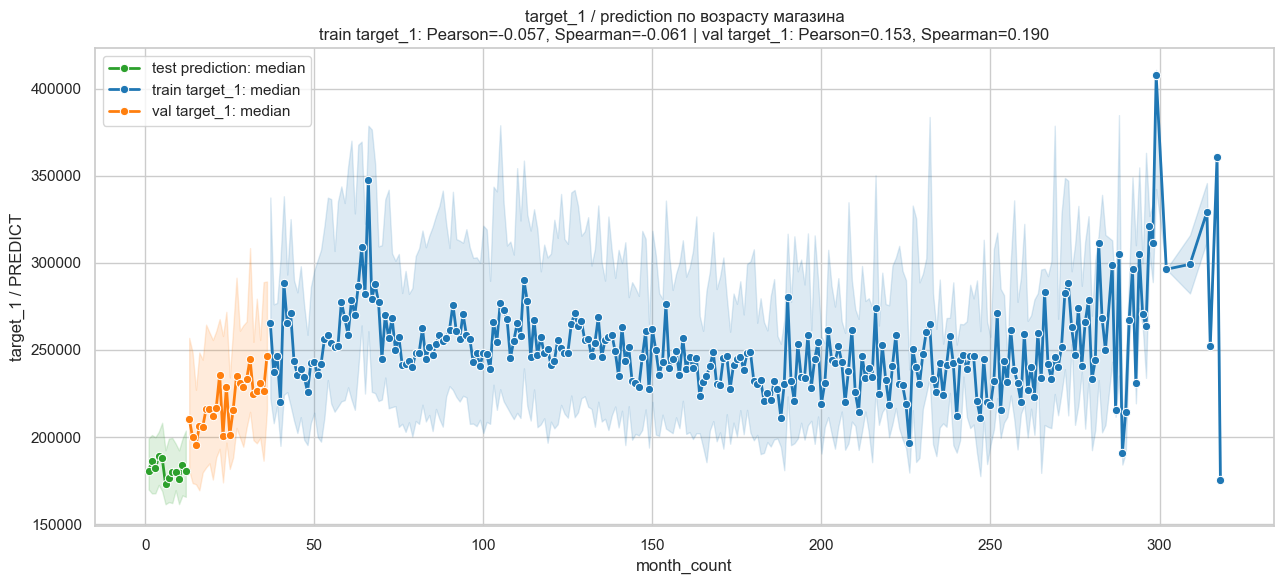

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', context='notebook')

DATA_DIR = Path('data')
SUBMISSION_PATH = Path('submissions') / 'best.csv'

train = pd.read_csv(DATA_DIR / 'train.csv')
val = pd.read_csv(DATA_DIR / 'val.csv')
holdout = pd.read_csv(DATA_DIR / 'holdout.csv')
best = pd.read_csv(SUBMISSION_PATH)

feature = 'month_count'
target = 'target_1'
pred_col = 'PREDICT'

holdout_pred = holdout.merge(
    best.rename(columns={'id': 'ID'}),
    on='ID',
    how='left',
)

if holdout_pred[pred_col].isna().any():
    raise ValueError('Some holdout rows did not match predictions from submissions/best.csv')


def prepare_part(df, dataset_name, value_col):
    part = df[[feature, value_col]].copy()
    part[value_col] = pd.to_numeric(part[value_col], errors='coerce')
    part = part.dropna(subset=[feature, value_col])
    part = part.rename(columns={value_col: 'value'})
    part['dataset'] = dataset_name
    return part

plot_df = pd.concat(
    [
        prepare_part(train, 'train target_1', target),
        prepare_part(val, 'val target_1', target),
        prepare_part(holdout_pred, 'test prediction', pred_col),
    ],
    ignore_index=True,
)

corr_text = []
for dataset_name, part in plot_df[plot_df['dataset'].ne('test prediction')].groupby('dataset'):
    pearson = part[feature].corr(part['value'], method='pearson')
    spearman = part[feature].corr(part['value'], method='spearman')
    corr_text.append(f'{dataset_name}: Pearson={pearson:.3f}, Spearman={spearman:.3f}')

trend = (
    plot_df
    .groupby(['dataset', feature])['value']
    .agg(
        median='median',
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        count='size',
    )
    .reset_index()
)

palette = {
    'train target_1': '#1f77b4',
    'val target_1': '#ff7f0e',
    'test prediction': '#2ca02c',
}

plt.figure(figsize=(13, 6))

for dataset_name, part in trend.groupby('dataset'):
    color = palette[dataset_name]
    plt.fill_between(
        part[feature],
        part['q25'],
        part['q75'],
        color=color,
        alpha=0.15,
    )
    sns.lineplot(
        data=part,
        x=feature,
        y='median',
        marker='o',
        linewidth=2,
        color=color,
        label=f'{dataset_name}: median',
    )

plt.title('target_1 / prediction по возрасту магазина\n' + ' | '.join(corr_text))
plt.xlabel('month_count')
plt.ylabel('target_1 / PREDICT')
plt.legend()
plt.tight_layout()
plt.show()


## Best submission vs default CatBoost по `month_count`

Обучаем дефолтный CatBoost на всех размеченных данных (`train + val`) без фича-инжиниринга и сравниваем его holdout-предсказания с `submissions/best.csv` по возрасту магазина.


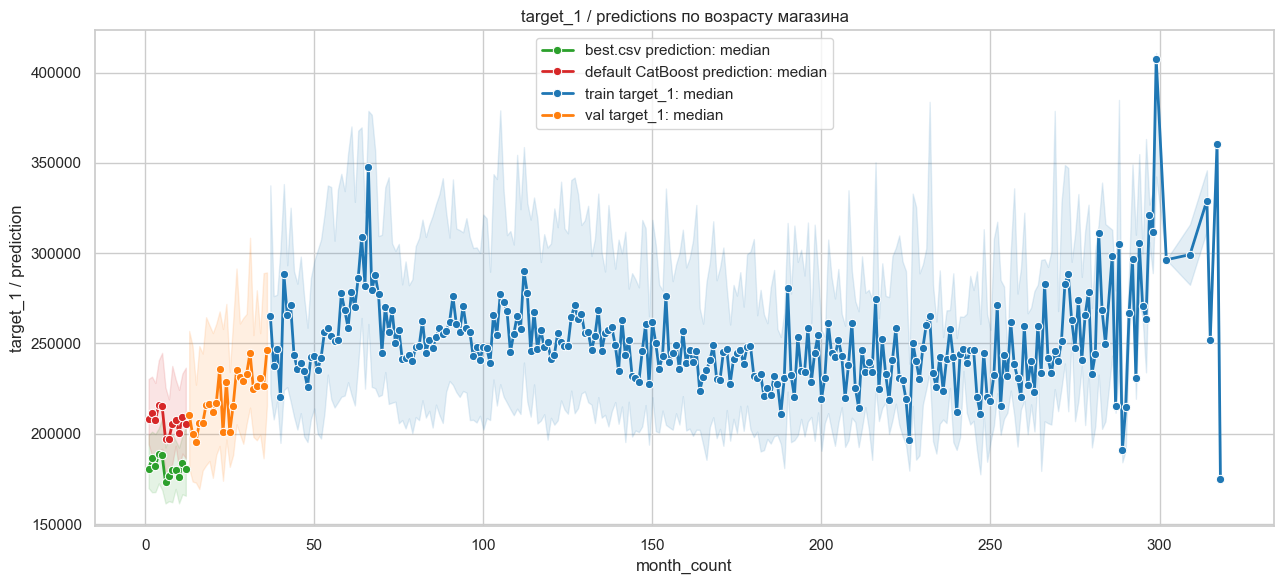

Holdout prediction summary:


,best_pred,default_catboost_pred
count,1322.00,1322.00
mean,187381.74,214231.74
std,33121.34,42212.83
min,133989.07,127771.48
25%,165299.11,185150.96
50%,180314.76,205602.62
75%,199427.04,231043.44
max,402373.90,470236.23


Median predictions by month_count:


,best_pred,default_catboost_pred
month_count,,
1,180484.42,208158.66
2,186376.04,211487.55
3,182089.02,207500.93
4,188909.62,216126.34
5,188119.50,215126.24
6,173038.45,197012.11
7,176356.61,197159.46
8,179745.27,205353.48
9,179703.87,207685.52


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

try:
    from catboost import CatBoostRegressor
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError('CatBoost is not installed. Install it with: pip install catboost') from exc

sns.set_theme(style='whitegrid', context='notebook')

DATA_DIR = Path('data')
SUBMISSION_PATH = Path('submissions') / 'best.csv'

train = pd.read_csv(DATA_DIR / 'train.csv')
val = pd.read_csv(DATA_DIR / 'val.csv')
holdout = pd.read_csv(DATA_DIR / 'holdout.csv')
best = pd.read_csv(SUBMISSION_PATH)

feature = 'month_count'
target = 'target_1'
pred_col = 'PREDICT'

for df in [train, val]:
    df[target] = pd.to_numeric(df[target], errors='coerce')

full_train = pd.concat([train, val], ignore_index=True)
full_train = full_train.dropna(subset=[target]).copy()

feature_cols = [col for col in holdout.columns if col != 'ID']
cat_cols = full_train[feature_cols].select_dtypes(include='object').columns.tolist()

X_train = full_train[feature_cols].copy()
y_train = full_train[target].astype(float)
X_test = holdout[feature_cols].copy()

for col in cat_cols:
    X_train[col] = X_train[col].astype('string').fillna('NA')
    X_test[col] = X_test[col].astype('string').fillna('NA')

model = CatBoostRegressor(
    random_seed=42,
    verbose=False,
    allow_writing_files=False,
)
model.fit(X_train, y_train, cat_features=cat_cols)

default_pred = model.predict(X_test)

holdout_pred = holdout[['ID', feature]].copy()
holdout_pred['default_catboost_pred'] = default_pred
holdout_pred = holdout_pred.merge(
    best.rename(columns={'id': 'ID', pred_col: 'best_pred'}),
    on='ID',
    how='left',
)

if holdout_pred['best_pred'].isna().any():
    raise ValueError('Some holdout rows did not match predictions from submissions/best.csv')


def prepare_part(df, dataset_name, value_col):
    part = df[[feature, value_col]].copy()
    part[value_col] = pd.to_numeric(part[value_col], errors='coerce')
    part = part.dropna(subset=[feature, value_col])
    part = part.rename(columns={value_col: 'value'})
    part['dataset'] = dataset_name
    return part

plot_df = pd.concat(
    [
        prepare_part(train, 'train target_1', target),
        prepare_part(val, 'val target_1', target),
        prepare_part(holdout_pred, 'best.csv prediction', 'best_pred'),
        prepare_part(holdout_pred, 'default CatBoost prediction', 'default_catboost_pred'),
    ],
    ignore_index=True,
)

trend = (
    plot_df
    .groupby(['dataset', feature])['value']
    .agg(
        median='median',
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        count='size',
    )
    .reset_index()
)

palette = {
    'train target_1': '#1f77b4',
    'val target_1': '#ff7f0e',
    'best.csv prediction': '#2ca02c',
    'default CatBoost prediction': '#d62728',
}

plt.figure(figsize=(13, 6))

for dataset_name, part in trend.groupby('dataset'):
    color = palette[dataset_name]
    plt.fill_between(
        part[feature],
        part['q25'],
        part['q75'],
        color=color,
        alpha=0.12,
    )
    sns.lineplot(
        data=part,
        x=feature,
        y='median',
        marker='o',
        linewidth=2,
        color=color,
        label=f'{dataset_name}: median',
    )

plt.title('target_1 / predictions по возрасту магазина')
plt.xlabel('month_count')
plt.ylabel('target_1 / prediction')
plt.legend()
plt.tight_layout()
plt.show()

print('Holdout prediction summary:')
display(
    holdout_pred[['best_pred', 'default_catboost_pred']]
    .describe()
    .round(2)
)

print('Median predictions by month_count:')
display(
    holdout_pred
    .groupby(feature)[['best_pred', 'default_catboost_pred']]
    .median()
    .round(2)
)


## Кластеризация объектов по числовым и бинарным фичам

Кластеризуем `train + val + holdout` без таргета: берем числовые/бинарные признаки, стандартизируем, строим KMeans и смотрим 2D PCA-проекцию. Это не для скоринга, а чтобы понять группы похожих объектов.


## Cluster features + CatBoost experiments

Проверяем, дают ли KMeans-кластеры по числовым/бинарным фичам прирост качества. Эксперименты одинаковые: `target_2`, обучение на train, оценка на `val[SUBFRMT == 1]`.


In [106]:
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from catboost import CatBoostRegressor
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError('CatBoost is not installed. Install it with: pip install catboost') from exc

DATA_DIR = Path('data')
train = pd.read_csv(DATA_DIR / 'train.csv')
val = pd.read_csv(DATA_DIR / 'val.csv')
holdout = pd.read_csv(DATA_DIR / 'holdout.csv')

TARGET = 'target_2'
TARGETS = ['target_1', 'target_2']
ID_COL = 'ID'
RANDOM_SEED = 42
N_CLUSTERS = 8

for df in [train, val]:
    for target in TARGETS:
        df[target] = pd.to_numeric(df[target], errors='coerce')


def mape_percent(y_true, y_pred):
    return mean_absolute_percentage_error(y_true, y_pred) * 100


def fit_cluster_features(train_df, extra_unsup_df=None, n_clusters=N_CLUSTERS):
    if extra_unsup_df is None:
        fit_df = train_df.drop(columns=TARGETS, errors='ignore').copy()
    else:
        fit_df = pd.concat(
            [
                train_df.drop(columns=TARGETS, errors='ignore'),
                extra_unsup_df.drop(columns=TARGETS, errors='ignore'),
            ],
            ignore_index=True,
        )

    numeric_cols = [
        col for col in fit_df.select_dtypes(include=[np.number]).columns
        if col != ID_COL
    ]

    prep = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ])
    X_fit = prep.fit_transform(fit_df[numeric_cols])

    kmeans = KMeans(n_clusters=n_clusters, random_state=RANDOM_SEED, n_init=30)
    kmeans.fit(X_fit)

    return {
        'numeric_cols': numeric_cols,
        'prep': prep,
        'kmeans': kmeans,
        'n_clusters': n_clusters,
    }


def add_cluster_features(df, cluster_state, add_distances=False):
    result = df.copy()
    numeric_cols = cluster_state['numeric_cols']
    X = cluster_state['prep'].transform(result[numeric_cols])

    cluster_id = cluster_state['kmeans'].predict(X)
    result['num_cluster'] = pd.Series(cluster_id, index=result.index).astype(str)

    if add_distances:
        distances = cluster_state['kmeans'].transform(X)
        for cluster_idx in range(cluster_state['n_clusters']):
            result[f'dist_to_cluster_{cluster_idx}'] = distances[:, cluster_idx]
        result['dist_to_assigned_cluster'] = distances[np.arange(len(result)), cluster_id]

    return result


def get_feature_cols(df):
    return [col for col in df.columns if col not in [ID_COL] + TARGETS]


def prepare_xy(df, feature_cols, target=TARGET):
    data = df.copy()
    data[target] = pd.to_numeric(data[target], errors='coerce')
    data = data.dropna(subset=[target])

    X = data[feature_cols].copy()
    y = data[target].astype(float)

    cat_cols = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
    if 'SUBFRMT' in X.columns and 'SUBFRMT' not in cat_cols:
        cat_cols.append('SUBFRMT')
    if 'num_cluster' in X.columns and 'num_cluster' not in cat_cols:
        cat_cols.append('num_cluster')

    for col in cat_cols:
        X[col] = X[col].astype('string').fillna('NA')

    return X, y, cat_cols


def run_catboost_experiment(name, train_df, valid_df, feature_cols):
    X_train, y_train, cat_cols = prepare_xy(train_df, feature_cols)
    X_valid, y_valid, _ = prepare_xy(valid_df, feature_cols)

    model = CatBoostRegressor(
        loss_function='MAE',
        eval_metric='MAPE',
        iterations=900,
        learning_rate=0.04,
        depth=6,
        l2_leaf_reg=6,
        random_seed=RANDOM_SEED,
        verbose=False,
        allow_writing_files=False,
    )
    model.fit(X_train, y_train, cat_features=cat_cols)
    pred = model.predict(X_valid)

    return {
        'experiment': name,
        'n_features': len(feature_cols),
        'train_rows': len(X_train),
        'valid_rows': len(X_valid),
        'mape_percent': mape_percent(y_valid, pred),
        'pred_mean': float(np.mean(pred)),
        'true_mean': float(np.mean(y_valid)),
        'bias_pred_minus_true': float(np.mean(pred - y_valid)),
    }, model

# Eval-домен похож на holdout: в val оставляем только SUBFRMT == 1.
val_eval = val[val['SUBFRMT'].eq(1)].copy()

# Для кластеров можно фититься только на train. Если хочешь transductive-вариант,
# раскомментируй extra_unsup_df с val+holdout.
# extra_unsup = pd.concat([val.drop(columns=TARGETS, errors='ignore'), holdout], ignore_index=True)
extra_unsup = None
cluster_state = fit_cluster_features(train, extra_unsup_df=extra_unsup, n_clusters=N_CLUSTERS)

train_cluster = add_cluster_features(train, cluster_state, add_distances=False)
val_cluster = add_cluster_features(val_eval, cluster_state, add_distances=False)

train_cluster_dist = add_cluster_features(train, cluster_state, add_distances=True)
val_cluster_dist = add_cluster_features(val_eval, cluster_state, add_distances=True)

base_feature_cols = get_feature_cols(train)
cluster_feature_cols = get_feature_cols(train_cluster)
cluster_dist_feature_cols = get_feature_cols(train_cluster_dist)

results = []
models = {}

row, model = run_catboost_experiment('baseline_no_clusters', train, val_eval, base_feature_cols)
results.append(row)
models[row['experiment']] = model

row, model = run_catboost_experiment('plus_cluster_id', train_cluster, val_cluster, cluster_feature_cols)
results.append(row)
models[row['experiment']] = model

row, model = run_catboost_experiment('plus_cluster_id_and_distances', train_cluster_dist, val_cluster_dist, cluster_dist_feature_cols)
results.append(row)
models[row['experiment']] = model

results_df = pd.DataFrame(results).sort_values('mape_percent')
display(results_df)

print('Cluster distribution, train vs val_eval:')
display(pd.DataFrame({
    'train_count': train_cluster['num_cluster'].value_counts().sort_index(),
    'val_eval_count': val_cluster['num_cluster'].value_counts().sort_index(),
    'train_share': train_cluster['num_cluster'].value_counts(normalize=True).sort_index(),
    'val_eval_share': val_cluster['num_cluster'].value_counts(normalize=True).sort_index(),
}).fillna(0).round(3))


,experiment,n_features,train_rows,valid_rows,mape_percent,pred_mean,true_mean,bias_pred_minus_true
1,plus_cluster_id,54,15109,2048,17.520084,246045.244704,234892.289736,11152.954968
2,plus_cluster_id_and_distances,63,15109,2048,17.658042,246667.400056,234892.289736,11775.110320
0,baseline_no_clusters,53,15109,2048,17.715167,246078.583280,234892.289736,11186.293544


Cluster distribution, train vs val_eval:


,train_count,val_eval_count,train_share,val_eval_share
num_cluster,,,,
0,4582,707,0.303,0.345
1,559,25,0.037,0.012
2,2767,412,0.183,0.201
3,2693,367,0.178,0.179
4,3135,243,0.207,0.119
5,844,121,0.056,0.059
6,323,165,0.021,0.081
7,206,8,0.014,0.004


## Визуализация кластеров по числовым/бинарным фичам

Восстановленный EDA-блок: KMeans по числовым/бинарным признакам без таргета, затем PCA 2D для визуализации кластеров и разреза train/val/holdout.


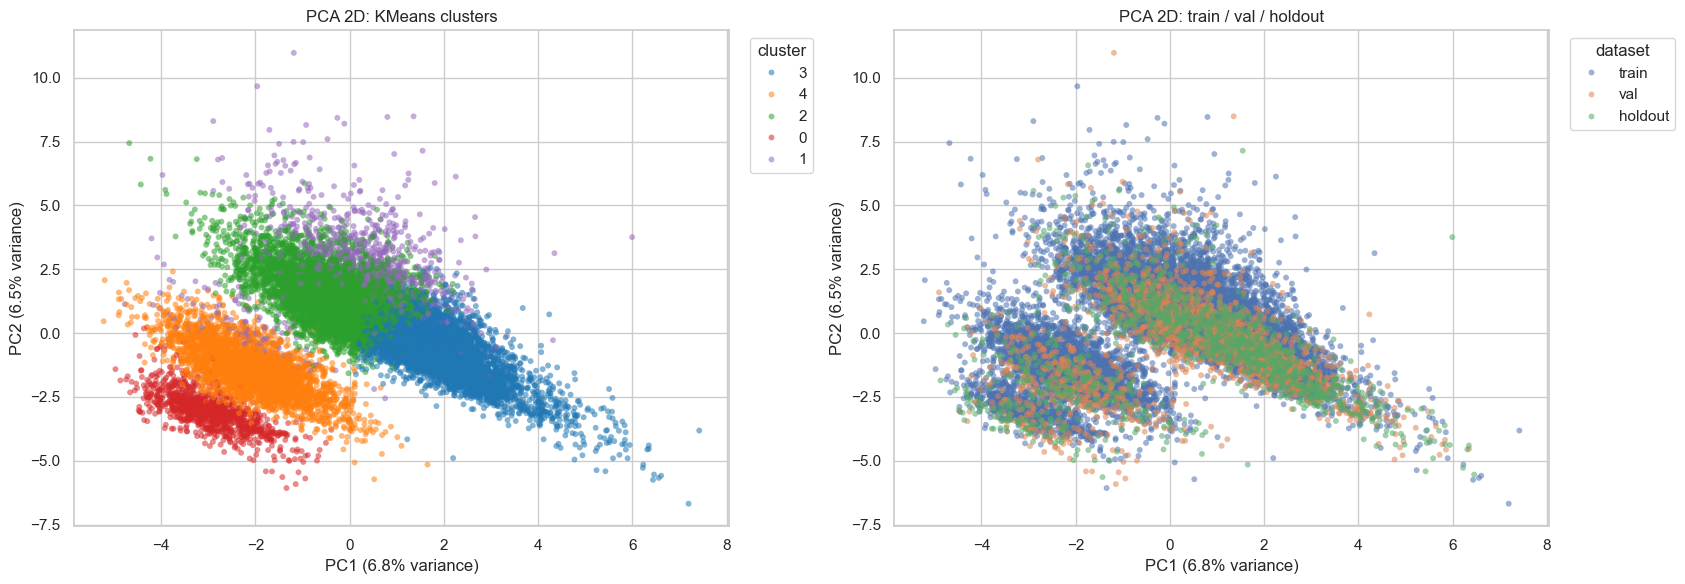

Numeric/binary features used: 49
['SUBFRMT', 'TRADE_SQUARE', 'HuffFamilies', 'HuffRelativeFamilies', 'HOSPITAL', 'KINDERGARTENS', 'BANKS', 'MK_ON_MM', 'ROUTES_CNT', 'CROSSWALK', 'CROSSROAD', 'DENSITY_FAMILY_TYPE', 'COLLEGES', 'huff_hotel', 'TRADING_PATCH_SCORE', 'RENT_HEX', 'IN_COAL_CITY', 'IN_OIL_CITY', 'CITY_TYPE', 'ON_DUPLICATE_ROAD', 'HUFF_RANK_COMPS_CANNIBALS', 'TOTAL_RANK_COMPS_CANNIBALS', 'INSIDE_YARD', 'ON_INSIDE_DISTRICT_ROAD', 'ON_MAIN_CITY_ROAD', 'ON_INTERCITY_HIGHWAY', 'ENTRANCE_TO_DISTRICT', 'ON_DISTRICT_BOTTOM', 'HUB', 'ALCOHOL', 'TOBACCO', 'LOCATION_MARKET', 'STATIONS', 'TRC', 'METRO', 'LOCATION_PARK', 'MINI_TRC', 'TRADING_PATCH', 'ENTIRE_DAY', 'MORNING_ROADSIDE', 'SEA', 'FLOORS_TZ', 'SNT', 'LOCATION_TYPE', 'DIST_TO_ADM_CENTER', 'PARKING', 'month_count', 'new_buildings', 'change_CA']
Cluster distribution by dataset, shares:


_dataset,holdout,train,val
num_cluster,,,
0,0.085,0.057,0.059
1,0.031,0.067,0.029
2,0.277,0.387,0.307
3,0.452,0.309,0.426
4,0.156,0.180,0.179


Cluster distribution by dataset, counts:


_dataset,holdout,train,val
num_cluster,,,
0,112,860,122
1,41,1009,61
2,366,5849,635
3,597,4674,880
4,206,2717,370


Top distinctive features per cluster, z-mean:


,num_cluster,feature,z_mean
110,0,INSIDE_YARD,3.980943
215,0,LOCATION_TYPE,-2.796923
120,0,ON_MAIN_CITY_ROAD,-1.613019
225,0,PARKING,-0.953151
45,0,CROSSWALK,-0.912907
55,0,DENSITY_FAMILY_TYPE,0.650466
90,0,CITY_TYPE,-0.543714
115,0,ON_INSIDE_DISTRICT_ROAD,-0.477778
186,1,TRADING_PATCH,2.818199
71,1,TRADING_PATCH_SCORE,2.448453


In [108]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', context='notebook')

DATA_DIR = Path('data')
train = pd.read_csv(DATA_DIR / 'train.csv')
val = pd.read_csv(DATA_DIR / 'val.csv')
holdout = pd.read_csv(DATA_DIR / 'holdout.csv')

TARGETS = ['target_1', 'target_2']
ID_COL = 'ID'
N_CLUSTERS = 5

train_x = train.drop(columns=TARGETS, errors='ignore').copy()
val_x = val.drop(columns=TARGETS, errors='ignore').copy()
holdout_x = holdout.copy()

train_x['_dataset'] = 'train'
val_x['_dataset'] = 'val'
holdout_x['_dataset'] = 'holdout'

all_df = pd.concat([train_x, val_x, holdout_x], ignore_index=True)

numeric_cols = [
    col for col in all_df.select_dtypes(include=[np.number]).columns
    if col != ID_COL
]

X = all_df[numeric_cols].copy()

prep = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
X_scaled = prep.fit_transform(X)

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=30)
all_df['num_cluster'] = kmeans.fit_predict(X_scaled).astype(str)

pca = PCA(n_components=2, random_state=42)
pca_2d = pca.fit_transform(X_scaled)
all_df['pca_1'] = pca_2d[:, 0]
all_df['pca_2'] = pca_2d[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

sns.scatterplot(
    data=all_df,
    x='pca_1',
    y='pca_2',
    hue='num_cluster',
    palette='tab10',
    s=18,
    alpha=0.55,
    linewidth=0,
    ax=axes[0],
)
axes[0].set_title('PCA 2D: KMeans clusters')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[0].legend(title='cluster', bbox_to_anchor=(1.02, 1), loc='upper left')

sns.scatterplot(
    data=all_df,
    x='pca_1',
    y='pca_2',
    hue='_dataset',
    s=18,
    alpha=0.55,
    linewidth=0,
    ax=axes[1],
)
axes[1].set_title('PCA 2D: train / val / holdout')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[1].legend(title='dataset', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

print(f'Numeric/binary features used: {len(numeric_cols)}')
print(numeric_cols)

print('Cluster distribution by dataset, shares:')
display(
    pd.crosstab(
        all_df['num_cluster'],
        all_df['_dataset'],
        normalize='columns',
    ).round(3)
)

print('Cluster distribution by dataset, counts:')
display(pd.crosstab(all_df['num_cluster'], all_df['_dataset']))

scaled_df = pd.DataFrame(X_scaled, columns=numeric_cols)
scaled_df['num_cluster'] = all_df['num_cluster'].values
cluster_profile = scaled_df.groupby('num_cluster')[numeric_cols].mean()

profile_long = (
    cluster_profile
    .reset_index()
    .melt(id_vars='num_cluster', var_name='feature', value_name='z_mean')
    .assign(abs_z=lambda x: x['z_mean'].abs())
    .sort_values(['num_cluster', 'abs_z'], ascending=[True, False])
)

print('Top distinctive features per cluster, z-mean:')
display(profile_long.groupby('num_cluster').head(8).drop(columns='abs_z'))


## Val-only CatBoost без `month_count` -> holdout predictions

Проверяем странную, но полезную гипотезу: обучаемся только на `val`, исключаем `month_count`, предсказываем holdout и смотрим среднее предсказание по месяцам.


Target: target_1
Train rows from val: 2068
Features used: 52
month_count in features: False


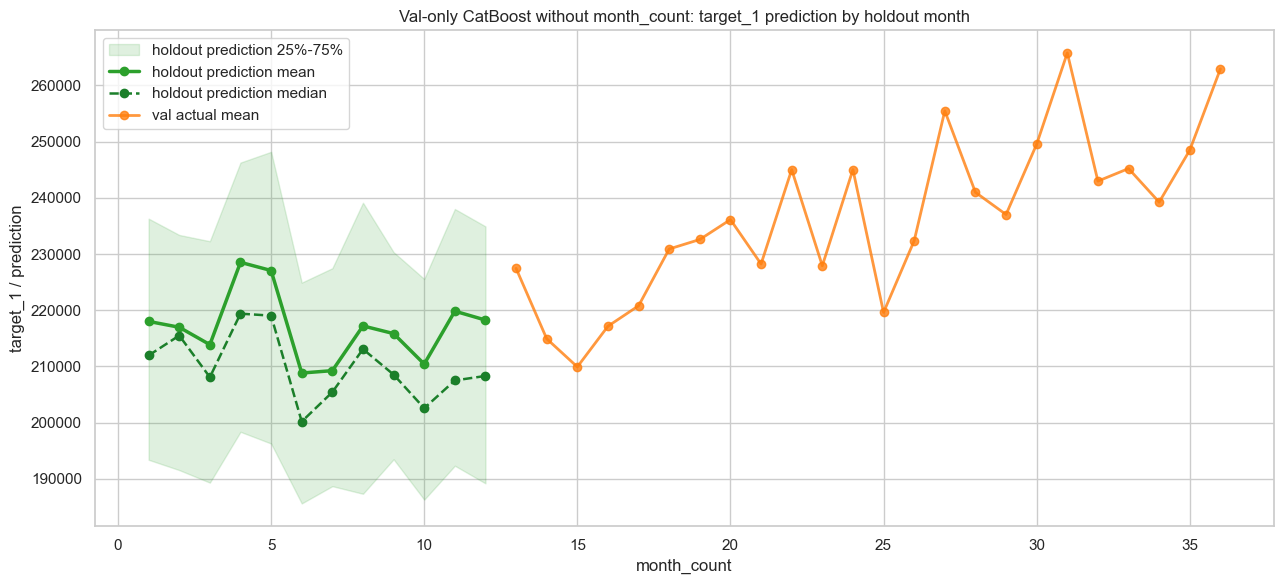

Holdout monthly predictions:


,month_count,mean,median,q25,q75,count
0,1,218019.09,211961.74,193411.62,236292.77,73
1,2,216979.25,215506.09,191578.56,233391.77,97
2,3,213887.75,208097.87,189347.31,232278.13,91
3,4,228525.02,219397.62,198384.58,246262.74,66
4,5,227067.96,219042.72,196300.02,248174.93,108
5,6,208838.69,200206.14,185646.65,224914.63,122
6,7,209262.00,205444.34,188718.45,227478.31,111
7,8,217217.10,213089.16,187364.18,239123.76,138
8,9,215852.85,208557.75,193503.82,230333.32,84
9,10,210428.59,202581.47,186325.08,225563.04,194


Holdout prediction summary:


,count,mean,std,min,25%,50%,75%,max
val_only_no_month_pred,1322.0,216153.71,38134.26,147570.2,189529.56,208123.88,233405.25,446904.87


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

try:
    from catboost import CatBoostRegressor
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError('CatBoost is not installed. Install it with: pip install catboost') from exc

sns.set_theme(style='whitegrid', context='notebook')

DATA_DIR = Path('data')
train = pd.read_csv(DATA_DIR / 'train.csv')
val = pd.read_csv(DATA_DIR / 'val.csv')
holdout = pd.read_csv(DATA_DIR / 'holdout.csv')

TARGET = 'target_1'
TARGETS = ['target_1', 'target_2']
DROP_FEATURES = ['ID', 'month_count'] + TARGETS

val[TARGET] = pd.to_numeric(val[TARGET], errors='coerce')
val_train = val.dropna(subset=[TARGET]).copy()

feature_cols = [col for col in holdout.columns if col not in DROP_FEATURES]
cat_cols = val_train[feature_cols].select_dtypes(include=['object', 'category', 'string']).columns.tolist()

X_val_train = val_train[feature_cols].copy()
y_val_train = val_train[TARGET].astype(float)
X_holdout = holdout[feature_cols].copy()

for col in cat_cols:
    X_val_train[col] = X_val_train[col].astype('string').fillna('NA')
    X_holdout[col] = X_holdout[col].astype('string').fillna('NA')

print(f'Target: {TARGET}')
print(f'Train rows from val: {len(X_val_train)}')
print(f'Features used: {len(feature_cols)}')
print('month_count in features:', 'month_count' in feature_cols)

model = CatBoostRegressor(
    loss_function='MAE',
    eval_metric='MAPE',
    iterations=800,
    learning_rate=0.04,
    depth=5,
    l2_leaf_reg=8,
    random_seed=42,
    verbose=False,
    allow_writing_files=False,
)
model.fit(X_val_train, y_val_train, cat_features=cat_cols)

holdout_pred = holdout[['ID', 'month_count']].copy()
holdout_pred['val_only_no_month_pred'] = model.predict(X_holdout)

monthly_pred = (
    holdout_pred
    .groupby('month_count')['val_only_no_month_pred']
    .agg(
        mean='mean',
        median='median',
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        count='size',
    )
    .reset_index()
    .sort_values('month_count')
)

val_monthly_actual = (
    val_train
    .groupby('month_count')[TARGET]
    .agg(mean='mean', median='median', count='size')
    .reset_index()
    .sort_values('month_count')
)

plt.figure(figsize=(13, 6))

plt.fill_between(
    monthly_pred['month_count'],
    monthly_pred['q25'],
    monthly_pred['q75'],
    color='#2ca02c',
    alpha=0.15,
    label='holdout prediction 25%-75%',
)
plt.plot(
    monthly_pred['month_count'],
    monthly_pred['mean'],
    marker='o',
    linewidth=2.5,
    color='#2ca02c',
    label='holdout prediction mean',
)
plt.plot(
    monthly_pred['month_count'],
    monthly_pred['median'],
    marker='o',
    linewidth=1.8,
    linestyle='--',
    color='#1b7f2a',
    label='holdout prediction median',
)

plt.plot(
    val_monthly_actual['month_count'],
    val_monthly_actual['mean'],
    marker='o',
    linewidth=2,
    color='#ff7f0e',
    alpha=0.8,
    label='val actual mean',
)

plt.title(f'Val-only CatBoost without month_count: {TARGET} prediction by holdout month')
plt.xlabel('month_count')
plt.ylabel(f'{TARGET} / prediction')
plt.legend()
plt.tight_layout()
plt.show()

print('Holdout monthly predictions:')
display(monthly_pred.round(2))

print('Holdout prediction summary:')
display(holdout_pred['val_only_no_month_pred'].describe().round(2).to_frame().T)
